# 🛡️ IEEE-CIS Fraud Detection: Baseline Pipeline (v0.6.0)

## 📝 Introduction
This notebook documents the development of the preprocessing and feature selection pipeline for the **IEEE-CIS Fraud Detection** challenge. The primary goal of version **v0.6.0** is to establish a robust data engineering foundation, focusing on:
1. **Memory Efficiency:** Handling large-scale datasets with optimized footprints.
2. **Data Consolidation:** Strategic joining of Transaction and Identity tables.
3. **Dimensionality Reduction:** Statistical filters for feature selection and redundancy removal.

---

## 📍 Implementation Summary (v0.6.0 Roadmap)
* [**Data Description**](#data-description) 📖 *Reference*

* [**1. Memory Management**](#memory-management) 🟢 *Completed*
    * *Implementation of `DataOptimizer` for statistical downcasting.*
* [**2. Data Consolidation (Vesta Joiner)**](#data-joining) 🟡 *In Progress*
    * *Optimized merge between `train_transaction` and `train_identity`.*
* [**3. Feature Selection: Correlation Filter**](#correlation) ⚪ *Pending*
    * *Redundancy removal via Pearson/Spearman correlation matrices.*
* [**4. Feature Selection: Information Value (IV) & WoE**](#iv-woe) ⚪ *Pending*
    * *Statistical importance ranking relative to the `isFraud` target.*
* [**5. Baseline Export**](#export) ⚪ *Pending*
    * *Final generation of the cleaned dataset for initial modeling.*

---

In [1]:
import datetime
import gc
import os
import sys
import time

import lightgbm as lgb
import numpy as np
import pandas as pd
from bayes_opt import BayesianOptimization
from matplotlib import pyplot as plt
from scipy.stats import ks_2samp as ks_2sample
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Add the project root to the sys.path so we can import 'model_track'
# This assumes the notebook is in 'examples/' or 'notebooks/'
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(os.path.join(project_root, "src"))

In [2]:
from model_track.binning.tree_binner import TreeBinner
from model_track.preprocessing.auditor import DataAuditor
from model_track.preprocessing.encoders import OrdinalEncoder
from model_track.preprocessing.memory import DataOptimizer
from model_track.preprocessing.types import TypeDetector
from model_track.stats.selection import StatisticalSelector
from model_track.woe.stability import CategoryMapper, WoeStability

# 1. Training Data Simulation (Reference)
df_a = pd.DataFrame(
    {
        "ID": [1, 2, 3, 4],
        "Vesta_Score": [0.85, 0.12, 0.33, 0.99],
        "Category": pd.Series(["A", "B", "A", "C"]).astype("category"),
        "Target": [0, 0, 1, 0],
        "Internal_Calculation": [10.0000001, 20.0, 30.0, 40.0],
    }
)

# 2. Test Data Simulation (With 3 intentional problems)
df_b = pd.DataFrame(
    {
        "ID": [5, 6],
        "Vesta_Score": [0.86, 0.13],
        # ERROR 1: 'Category' is Object here, not Category
        "Category": ["A", "D"],
        # ERROR 2: 'Internal_Calculation' has precision error > 1e-6
        "Internal_Calculation": [10.00002, 20.0],
        # ERROR 3: 'New_Feature' only exists in Test
        "New_Feature": [1, 0],
        # NOTE: 'Target' doesn't exist in Test (common in production)
    }
)

# 3. Executing Comparison
auditor = DataAuditor(target="Target")

print("🧪 Starting Audit Simulation...")
res = auditor.compare_schemas(df_a, df_b, tolerance=1e-6)

print(f"\n📌 Columns only in A: {res['only_in_a']}")
# Expected: ['Target'] (auditor ignores target if configured in init)

print(f"📌 Columns only in B: {res['only_in_b']}")
# Expected: ['New_Feature']

print(f"⚠️ Columns with Value Divergence: {res['diff_value_cols']}")
# Expected: ['Internal_Calculation'] because the difference 0.0000199 > 1e-6

# 4. Verifying Test Summary to see if 'object' vs 'category' type appears
print("\n📊 B Dataset Summary:")
summary_test = auditor.get_summary(df_b)
display(summary_test[["dtype", "unique_examples"]])

🧪 Starting Audit Simulation...

📌 Columns only in A: ['Target']
📌 Columns only in B: ['New_Feature']
⚠️ Columns with Value Divergence: ['Category', 'Internal_Calculation', 'Vesta_Score', 'ID']

📊 B Dataset Summary:


,dtype,unique_examples
column_name,,
ID,int64,"5, 6"
Vesta_Score,float64,"0.13, 0.86"
Category,object,"A, D"
Internal_Calculation,float64,"10.00002, 20.0"
New_Feature,int64,"0, 1"


In [3]:
res

{'only_in_a': ['Target'],
 'only_in_b': ['New_Feature'],
 'diff_value_cols': ['Category', 'Internal_Calculation', 'Vesta_Score', 'ID']}

<a id='data-description'></a>
## 📊 Data Description
The dataset consists of two main files linked by `TransactionID`. 

### 💳 Transaction Table (`train_transaction.csv`)
* **TransactionDT:** Timestep from a given reference datetime (not a real timestamp).
* **TransactionAmt:** Transaction payment amount in USD.
* **ProductCD:** Product code for each transaction.
* **card1 - card6:** Payment card information (card type, card bank, country, etc.).
* **addr1, addr2:** Address information.
* **dist:** Distance between address and billing information.
* **P_emaildomain / R_emaildomain:** Purchaser and recipient email domains.
* **C1 - C14:** Counting variables (e.g., how many addresses are found associated with the card).
* **D1 - D15:** Timedeltas, such as days between previous transactions.
* **M1 - M9:** Match indicators (names on card, address, etc.).
* **V1 - V339:** Vesta engineered features (ranking, counting, and other relations).

### 🆔 Identity Table (`train_identity.csv`)
Variables in this table are network connection information and digital signatures associated with transactions.
* **DeviceType:** Mobile or Desktop.
* **DeviceInfo:** Specific device models.
* **id_01 - id_38:** Behavioral and identity features.

---

<a id='memory-management'></a>
## 📦 1. Data Loading and Memory Management (DataOptimizer)
The **IEEE-CIS** dataset contains over 400 columns and millions of rows. Loading this into standard 64-bit containers can easily exceed 2GB+ of RAM. Our `DataOptimizer` performs statistical downcasting to minimize the footprint without losing precision.

In [4]:
# 1. Path configuration (adjust as per your Local structure)
folder_path = "notebooks/data/ieee-fraud-detection/"

# --- TRAIN DATASET PROCESSING ---
print("📦 [STEP 1] PROCESSING TRAIN DATA")

print("\n🚀 Loading & Optimizing Identity (Train):")
# Load and pass through the optimizer in the same line to save overhead
df_train_identity = pd.read_csv(f"{folder_path}train_identity.csv")
# Optimize and replace old variable
df_train_identity = DataOptimizer.reduce_mem_usage(df_train_identity)
print(f"Memory Identity: {df_train_identity.memory_usage().sum() / 1024**2:.2f} MB")

print("\n🚀 Loading & Optimizing Transactions (Train):")
train_transaction = pd.read_csv(f"{folder_path}train_transaction.csv")
train_transaction = DataOptimizer.reduce_mem_usage(train_transaction)

print("\n🔗 Joining Train Datasets...")
df_train = pd.merge(train_transaction, df_train_identity, on="TransactionID", how="left")

# CRITICAL CLEANUP: Delete original tables after merging
del df_train_identity, train_transaction
gc.collect()
print("✅ Train fragments cleared from RAM.")

print("-" * 50)

# --- TEST DATASET PROCESSING ---
print("📦 [STEP 2] PROCESSING TEST DATA")

print("\n🚀 Loading & Optimizing Identity (Test):")
df_test_identity = pd.read_csv(f"{folder_path}test_identity.csv")
df_test_identity = DataOptimizer.reduce_mem_usage(df_test_identity)

print("\n🚀 Loading & Optimizing Transactions (Test):")
test_transaction = pd.read_csv(f"{folder_path}test_transaction.csv")
test_transaction = DataOptimizer.reduce_mem_usage(test_transaction)

print("\n🔗 Joining Test Datasets...")
df_test = pd.merge(test_transaction, df_test_identity, on="TransactionID", how="left")

# CRITICAL CLEANUP: Delete original test tables
del df_test_identity, test_transaction
gc.collect()
print("✅ Test fragments cleared from RAM.")

# --- FINAL MEMORY SUMMARY ---
print("\n" + "=" * 50)
print("🔥 FINAL PIPELINE STATUS:")
print(f"TRAIN: {df_train.shape[0]} rows | {df_train.shape[1]} columns")
print(f"TEST:  {df_test.shape[0]} rows | {df_test.shape[1]} columns")
print(f"Final TRAIN Memory: {df_train.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Final TEST Memory:  {df_test.memory_usage().sum() / 1024**2:.2f} MB")
print("=" * 50)

# Loading sample submission for future reference
sub = pd.read_csv(f"{folder_path}sample_submission.csv")

📦 [STEP 1] PROCESSING TRAIN DATA

🚀 Loading & Optimizing Identity (Train):
📉 Initial Memory: 45.12 MB
✅ Final Memory:   16.05 MB
🚀 Reduction:      29.07 MB (64.4%)
Memory Identity: 16.05 MB

🚀 Loading & Optimizing Transactions (Train):
📉 Initial Memory: 1775.15 MB
✅ Final Memory:   861.11 MB
🚀 Reduction:      914.04 MB (51.5%)

🔗 Joining Train Datasets...
✅ Train fragments cleared from RAM.
--------------------------------------------------
📦 [STEP 2] PROCESSING TEST DATA

🚀 Loading & Optimizing Identity (Test):
📉 Initial Memory: 44.39 MB
✅ Final Memory:   15.80 MB
🚀 Reduction:      28.59 MB (64.4%)

🚀 Loading & Optimizing Transactions (Test):
📉 Initial Memory: 1519.24 MB
✅ Final Memory:   738.36 MB
🚀 Reduction:      780.87 MB (51.4%)

🔗 Joining Test Datasets...
✅ Test fragments cleared from RAM.

🔥 FINAL PIPELINE STATUS:
TRAIN: 590540 rows | 434 columns
TEST:  506691 rows | 433 columns
Final TRAIN Memory: 924.29 MB
Final TEST Memory:  792.58 MB


<a id='data-diagnostics'></a>
## 🔍 2. Data Inventory & Missing Value Analysis
Using our `model_track` library to audit the merged datasets. We need to:
1. Identify the **Target** column and ensure it only exists in the Train set.
2. Analyze the **Missing Values** (NaNs) to prioritize future imputation or column removal.

In [5]:
# 1. Check for Target Column presence
target = "isFraud"
has_target_train = target in df_train.columns
has_target_test = target in df_test.columns

print(f"🛠️ Target Check ({target}):")
print(f"  - Present in Train: {'✅ Yes' if has_target_train else '❌ No'}")
print(f"  - Present in Test:  {'❌ Yes (Wait, what?)' if has_target_test else '✅ No'}")

column_time_dt = "TransactionDT"
# 2 Consistency Check: Identify columns in Train not in Test (excluding target)
cols_not_in_test = [
    c for c in df_train.columns if c not in df_test.columns and c not in [target, column_time_dt]
]
print(f"\n⚠️ Columns in Train but missing in Test (excluding target): {cols_not_in_test}")
feat_cols = [
    c for c in df_train.columns if c in df_test.columns and c not in [target, column_time_dt]
]

df_train = df_train[feat_cols + [target, column_time_dt]]
df_test = df_test[feat_cols + [column_time_dt]]
# 2. Get Summary using the library
print("\n📊 Generating Dataset Summary...")

auditor = DataAuditor(target="isFraud")
df_train_summary = auditor.get_summary(df_train[feat_cols]).reset_index()

# 3. Sorting by Missing Values (%)
# Geralmente o get_summary retorna um DataFrame com a coluna 'missing_pct' or 'null_count'
df_train_summary_sorted = df_train_summary.sort_values(by="pct_na", ascending=False)

print("\n🔝 Top 15 Columns with most Missing Values (Train):")
display(df_train_summary_sorted.head(15))


print("\n🔝 Top 15 Columns with most top class pct(Train):")
display(df_train_summary.sort_values(by="top_class_pct", ascending=False).head(15))

🛠️ Target Check (isFraud):
  - Present in Train: ✅ Yes
  - Present in Test:  ✅ No

⚠️ Columns in Train but missing in Test (excluding target): ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

📊 Generating Dataset Summary...

🔝 Top 15 Columns with most Missing Values (Train):


,column_name,dtype,null_count,pct_na,n_distinct,min,max,top_class,top_class_pct,unique_examples
12,dist2,float32,552913,93.628374,1751,0.0,11623.000000,7.0,0.963017,Too many values...
35,D7,float32,551623,93.409930,597,0.0,843.000000,0.0,3.578928,Too many values...
41,D13,float32,528588,89.509263,577,0.0,847.000000,0.0,8.270397,Too many values...
42,D14,float32,528353,89.469469,802,-193.0,878.000000,0.0,7.665188,Too many values...
40,D12,float32,525823,89.041047,635,-83.0,648.000000,0.0,7.240153,Too many values...
34,D6,float32,517353,87.606767,829,-83.0,873.000000,0.0,7.752565,Too many values...
36,D8,float32,515614,87.312290,12353,0.0,1707.791626,0.791666,0.228774,Too many values...
37,D9,float32,515614,87.312290,24,0.0,0.958333,0.791666,0.912385,Too many values...
210,V158,float32,508595,86.123717,25,0.0,24.000000,1.0,9.270160,Too many values...
207,V155,float32,508595,86.123717,25,0.0,24.000000,1.0,9.920412,Too many values...



🔝 Top 15 Columns with most top class pct(Train):


,column_name,dtype,null_count,pct_na,n_distinct,min,max,top_class,top_class_pct,unique_examples
357,V305,float32,12,0.002032,2,1.0,2.0,1.0,99.997291,"1.0, 2.0"
159,V107,float32,314,0.053172,2,0.0,1.0,1.0,99.904833,"0.0, 1.0"
169,V117,float32,314,0.053172,4,0.0,3.0,1.0,99.823721,"0.0, 1.0, 2.0, 3.0"
171,V119,float32,314,0.053172,4,0.0,3.0,1.0,99.815423,"0.0, 1.0, 2.0, 3.0"
170,V118,float32,314,0.053172,4,0.0,3.0,1.0,99.779524,"0.0, 1.0, 2.0, 3.0"
172,V120,float32,314,0.053172,4,0.0,3.0,1.0,99.776137,"0.0, 1.0, 2.0, 3.0"
174,V122,float32,314,0.053172,4,0.0,3.0,1.0,99.713144,"0.0, 1.0, 2.0, 3.0"
163,V111,float32,314,0.053172,10,0.0,9.0,1.0,99.654384,"0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0"
165,V113,float32,314,0.053172,10,0.0,9.0,1.0,99.598334,"0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0"
17,C3,float32,0,0.000000,27,0.0,26.0,0.0,99.588682,Too many values...


In [6]:
# 1. Define thresholds
NULL_THRESHOLD = 98.0
CONST_THRESHOLD = 99.0

# 2. Identify columns - Ensuring we get the string names
# We access the 'column_name' column specifically
cols_to_drop_null = df_train_summary[df_train_summary["pct_na"] > NULL_THRESHOLD][
    "column_name"
].tolist()
cols_to_drop_const = df_train_summary[df_train_summary["top_class_pct"] > CONST_THRESHOLD][
    "column_name"
].tolist()

# Combine and remove duplicates
all_cols_to_drop = list(set(cols_to_drop_null + cols_to_drop_const))

# 🛑 Guardrail: Remove names only if they actually exist in the dataframe
all_cols_to_drop = [
    c for c in all_cols_to_drop if c in df_train.columns and c not in [target, "TransactionID"]
]

print(f"📉 Found {len(cols_to_drop_null)} columns with > {NULL_THRESHOLD}% NaNs.")
print(f"📉 Found {len(cols_to_drop_const)} columns with > {CONST_THRESHOLD}% top class.")
print(f"🗑️ Total unique columns to be removed: {len(all_cols_to_drop)}")

# 3. Perform the drop
df_train.drop(columns=all_cols_to_drop, inplace=True)
df_test.drop(columns=all_cols_to_drop, inplace=True)

print(f"\n✅ Cleanup complete. Dropped: {all_cols_to_drop[:5]}...")

📉 Found 0 columns with > 98.0% NaNs.
📉 Found 15 columns with > 99.0% top class.
🗑️ Total unique columns to be removed: 15

✅ Cleanup complete. Dropped: ['V122', 'V114', 'V119', 'V107', 'V108']...


In [7]:
# --- FINAL MEMORY SUMMARY ---
print("\n" + "=" * 50)
print("🔥 FINAL PIPELINE STATUS:")
print(f"TRAIN: {df_train.shape[0]} rows | {df_train.shape[1]} columns")
print(f"TEST:  {df_test.shape[0]} rows | {df_test.shape[1]} columns")
print(f"Final TRAIN Memory: {df_train.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Final TEST Memory:  {df_test.memory_usage().sum() / 1024**2:.2f} MB")
print("=" * 50)


🔥 FINAL PIPELINE STATUS:
TRAIN: 590540 rows | 381 columns
TEST:  506691 rows | 380 columns
Final TRAIN Memory: 829.09 MB
Final TEST Memory:  710.90 MB


## 3. Data Type Detection

In [8]:
def apply_month_year_engineering(df):
    # 1. Set Anchor Date
    start_date = datetime.datetime.strptime("2017-12-01", "%Y-%m-%d")

    # 2. Convert seconds to real DateTime
    # Use timedelta to add seconds to the start date
    df["dt_temp"] = df["TransactionDT"].apply(lambda x: start_date + datetime.timedelta(seconds=x))

    # 3. Create Year-Month column (Numeric YYYYMM for easy sorting)
    df["tm_yymm"] = df["dt_temp"].dt.year * 100 + df["dt_temp"].dt.month

    # 4. Create Year-Month column (String YYYY-MM for plotting)
    df["tm_yymm_str"] = df["dt_temp"].dt.strftime("%Y-%m")

    # Remove temporary column to save memory
    df.drop(columns=["dt_temp"], inplace=True)

    return df


# Applying to both datasets
df_train = apply_month_year_engineering(df_train)
df_test = apply_month_year_engineering(df_test)

print("✅ Period columns created: 'tm_yymm' (Int) and 'tm_yymm_str' (String)")
display(df_train[["TransactionDT", "tm_yymm", "tm_yymm_str"]].head())

✅ Period columns created: 'tm_yymm' (Int) and 'tm_yymm_str' (String)


,TransactionDT,tm_yymm,tm_yymm_str
0,86400,201712,2017-12
1,86401,201712,2017-12
2,86469,201712,2017-12
3,86499,201712,2017-12
4,86506,201712,2017-12


In [9]:
# %% Detecting Data Types

print("🔍 Detecting variable profiles...")
detector = TypeDetector(
    target="isFraud",
    id_cols=["TransactionID"],
    datetime_cols=["TransactionDT", "tm_yymm", "tm_yymm_str"],  # Informing explicitly
)
feature_types = detector.detect(df_train)

for k, v in feature_types.items():
    print(f"{k.upper():<20} | {len(v):<5}")

🔍 Detecting variable profiles...
DATETIME             | 3    
CATEGORICAL_LOW      | 109  
CATEGORICAL_HIGH     | 3    
NUMERICAL            | 266  
ID_LIKE              | 0    


In [10]:
feature_types.get("categorical_high")

['P_emaildomain', 'R_emaildomain', 'DeviceInfo']

## Split Train Data into Dev and OOT (Out-of-Time) 

We will split the training data according to dates, using the first months as dev and the last two as oot.

In [11]:
# We will split the training data according to dates, using the first months as dev and the last two as oot.
df_train["Sample"] = df_train["tm_yymm"].apply(lambda x: "dev" if x <= 201804 else "oot")
print("✅ 'Sample' column created based on 'tm_yymm'.")
display(df_train[["tm_yymm", "Sample"]].drop_duplicates().sort_values(by="tm_yymm").head(10))

✅ 'Sample' column created based on 'tm_yymm'.


,tm_yymm,Sample
0,201712,dev
134339,201801,dev
226849,201802,dev
312574,201803,dev
414542,201804,dev
498113,201805,oot
587786,201806,oot


<a id='tree-binning'></a>
## 🌳 4. Supervised Binning (TreeBinner)
We will now use a Decision Tree-based approach to discretize continuous features. 
* **Mechanism:** The `TreeBinner` finds optimal split points by maximizing the information gain relative to the `isFraud` target.
* **Benefit:** This automatically handles outliers and non-linear relationships by grouping values with similar fraud probabilities.
* **Post-Processing:** All resulting bins will be treated as categorical strings, with `NaN` values mapped to a dedicated `"N/A"` category.

In [12]:
# 1. Identify potential continuous features
numerical_features = feature_types.get("numerical")
categorical_features = feature_types.get("categorical_low")

bins_dict = {}
binners_map = {}
new_cols_train = {}
new_cols_test = {}

start_total = time.time()

for col in numerical_features:
    binner = TreeBinner(max_depth=3, min_samples_leaf=100)

    # Fit only on DEV
    binner.fit(df_train.query("Sample == 'dev'"), column=col, target="isFraud")

    # Store results in dictionaries to avoid fragmentation
    new_cols_train[f"{col}_bin"] = binner.transform(df_train, column=col)
    new_cols_test[f"{col}_bin"] = binner.transform(df_test, column=col)

    binners_map[col] = binner

# Final concatenation (prevents PerformanceWarning)
df_train = pd.concat([df_train, pd.DataFrame(new_cols_train, index=df_train.index)], axis=1)
df_test = pd.concat([df_test, pd.DataFrame(new_cols_test, index=df_test.index)], axis=1)

print(f"✅ Binning completed for {len(numerical_features)} columns.")
print(f"\n✅ TreeBinner finished in {time.time() - start_total:.2f} seconds.")

# Clean up temporary dictionaries
del new_cols_train, new_cols_test
gc.collect()

# 4. Final Verification
numerical_features_bin = [c for c in df_train.columns if c.endswith("_bin")]
print(f"Final Binned Columns Created: {len(numerical_features_bin)}")

display(df_train[numerical_features_bin].head())

✅ Binning completed for 266 columns.

✅ TreeBinner finished in 64.61 seconds.
Final Binned Columns Created: 266


,TransactionAmt_bin,card1_bin,card2_bin,card3_bin,card5_bin,addr1_bin,addr2_bin,dist1_bin,dist2_bin,C1_bin,...,V330_bin,V331_bin,V332_bin,V333_bin,V334_bin,V335_bin,V336_bin,V337_bin,V338_bin,V339_bin
0,"(24.893, 135.238]","(13334.5, 15066.5]",N/A,"(149.5, 174.5]","(137.5, 162.5]","(198.5, 535.5]","(68.5, 90.5]","(3.5, 78.5]",N/A,"(0.5, 1.5]",...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,"(24.893, 135.238]","(-inf, 8754.0]","(201.5, 499.5]","(149.5, 174.5]","(-inf, 108.0]","(198.5, 535.5]","(68.5, 90.5]",N/A,N/A,"(0.5, 1.5]",...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
2,"(24.893, 135.238]","(-inf, 8754.0]","(201.5, 499.5]","(149.5, 174.5]","(162.5, 168.0]","(198.5, 535.5]","(68.5, 90.5]","(78.5, 958.5]",N/A,"(0.5, 1.5]",...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,"(24.893, 135.238]","(15066.5, inf]","(553.5, inf]","(149.5, 174.5]","(108.0, 136.5]","(198.5, 535.5]","(68.5, 90.5]",N/A,N/A,"(1.5, 4.5]",...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
4,"(24.893, 135.238]","(-inf, 8754.0]","(500.5, 553.5]","(149.5, 174.5]","(-inf, 108.0]","(198.5, 535.5]","(68.5, 90.5]",N/A,N/A,"(0.5, 1.5]",...,"(-inf, 0.5]","(-inf, 2.5]","(-inf, 3.24]","(-inf, 2.5]","(-inf, 15.5]","(-inf, 59.0]","(-inf, 5.5]","(-inf, 2.5]","(-inf, 2.5]","(-inf, 2.5]"


<a id='iv-cramers'></a>
## 📊 5. Statistical Selection: IV & Cramer's V
To finalize our feature set, we apply a dual-stage filter:
1. **Information Value (IV):** Drop features with $IV < 0.10$ (Weak predictive power).
2. **Cramer's V:** Identify redundant categorical pairs. If $V > 0.80$, we keep the feature with the **highest IV**.

In [13]:
# %% [NB Step 5] Statistical Selection: IV & Cramer's V

# Garantimos que todas as variáveis sejam listas (usando [] como fallback)
# Isso evita o erro 'TypeError: can only concatenate list (not "NoneType") to list'
eval_numerical = numerical_features_bin if numerical_features_bin is not None else []
eval_cat_low = categorical_features if categorical_features is not None else []
eval_cat_high = feature_types.get("categorical_high", [])

features_to_evaluate = eval_numerical + eval_cat_low + eval_cat_high

# Removemos duplicatas e garantimos que as colunas existam no DataFrame atual
# Removemos duplicatas usando set comprehension e garantimos que as colunas existam
features_to_evaluate = list({f for f in features_to_evaluate if f in df_train.columns})

selector = StatisticalSelector(iv_threshold=0.10, cramers_threshold=0.70, sample_size=50000)

print(f"📉 Evaluating {len(features_to_evaluate)} features...")

# O Fit toma as decisões com base no Train
selector.fit(df_train, target="isFraud", features=features_to_evaluate)

# O Transform executa a remoção no Train e no Test
df_train = selector.transform(df_train)
df_test = selector.transform(df_test)

print(f"\n❌ Dropped features: {len(selector.dropped_features_)}")
print(f"✅ Final features kept: {len(selector.selected_features_)}")

final_features = selector.selected_features_

# Exibindo o Top 10 IVs para Audit visual
if selector.iv_results_:
    iv_df = pd.DataFrame(list(selector.iv_results_.items()), columns=["feature", "iv"])
    display(iv_df.sort_values(by="iv", ascending=False).head(10))

# Atualizando as listas de variáveis finais (filtrando as que sobreviveram à seleção)
selected_numerical_features_bin = [f for f in eval_numerical if f in selector.selected_features_]
selected_categorical_features = [f for f in eval_cat_low if f in selector.selected_features_]

gc.collect()

📉 Evaluating 378 features...

❌ Dropped features: 240
✅ Final features kept: 138


,feature,iv
51,DeviceInfo,1.967828
274,V258_bin,0.988569
109,V257_bin,0.927573
285,V201_bin,0.924113
244,V200_bin,0.886558
264,V52,0.879626
268,V243_bin,0.859018
106,V246_bin,0.857816
138,V187_bin,0.852337
338,V189_bin,0.841501


0

In [14]:
auditor = DataAuditor(target="isFraud")
auditor.get_summary(df_train[feature_types.get("datetime")]).sort_values(
    by="n_distinct", ascending=False
)

,dtype,null_count,pct_na,n_distinct,min,max,top_class,top_class_pct,unique_examples
column_name,,,,,,,,,
TransactionDT,int32,0,0.0,573349,86400.0,15811131.0,9474817,0.001355,Too many values...
tm_yymm,int32,0,0.0,7,201712.0,201806.0,201712,22.748501,"201712, 201801, 201802, 201803, 201804, 201805..."
tm_yymm_str,object,0,0.0,7,NaN,NaN,2017-12,22.748501,"2017-12, 2018-01, 2018-02, 2018-03, 2018-04, 2..."


In [15]:
auditor.get_summary(df_train).sort_values(by="n_distinct", ascending=False)

,dtype,null_count,pct_na,n_distinct,min,max,top_class,top_class_pct,unique_examples
column_name,,,,,,,,,
TransactionID,int32,0,0.000000,590540,2987000.0,3577539.0,2987000,0.000169,Too many values...
TransactionDT,int32,0,0.000000,573349,86400.0,15811131.0,9474817,0.001355,Too many values...
V307,float32,12,0.002032,37367,0.0,145765.0,0.0,53.620415,Too many values...
V127,float32,314,0.053172,24414,0.0,160000.0,0.0,62.075050,Too many values...
V308,float32,12,0.002032,23064,0.0,108800.0,0.0,71.538592,Too many values...
...,...,...,...,...,...,...,...,...,...
card6,category,1571,0.266028,4,NaN,NaN,debit,74.497578,"charge card, credit, debit, debit or credit"
C5_bin,object,0,0.000000,4,NaN,NaN,"(-inf, 0.5]",63.066854,"(-inf, 0.5], (0.5, 1.5], (1.5, 107.5], (107.5,..."
V35,float32,168969,28.612626,4,0.0,3.0,1.0,37.488908,"0.0, 1.0, 2.0, 3.0"


## Bayesian Optimization using LightGBM

In [16]:
# %% [NB Step 6] Pre-LGBM: Ordinal Encoding
# Initialize our Encoder (unseen_value=-1 is the safe default for tree-based models)
encoder = OrdinalEncoder(unseen_value=-1)

print(f"⚙️ Encoding {len(final_features)} features for LightGBM...")

# FIT: Learn mapping ONLY on the 'dev' set (Avoids data leakage from future/OOT)
encoder.fit(df_train.query("Sample == 'dev'"), columns=final_features)

# TRANSFORM: Apply to Train (Dev + OOT) and Test sets
df_train_lgbm = encoder.transform(df_train, columns=final_features)
df_test_lgbm = encoder.transform(df_test, columns=final_features)

print("✅ Encoding completed successfully!")
display(df_train_lgbm[final_features].head())

⚙️ Encoding 138 features for LightGBM...
✅ Encoding completed successfully!


,DeviceInfo,V258_bin,V201_bin,V52,V246_bin,V187_bin,C12_bin,V199_bin,C8_bin,V245_bin,...,V5,V143_bin,V82,V66,V140_bin,V61,V147_bin,V292_bin,TransactionAmt_bin,V307_bin
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,1
2,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
3,0,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,2
4,1,1,1,0,1,1,0,1,1,1,...,1,1,2,1,1,1,1,0,0,1


In [17]:
# %% [NB Step 7] LightGBM Preparation and Bayesian Optimization

# Create masks only (memory efficient)
dev_mask = df_train_lgbm["Sample"] == "dev"
oot_mask = df_train_lgbm["Sample"] == "oot"


def lgbm_cl_bo(
    max_depth, num_leaves, learning_rate, feature_fraction, bagging_fraction, lambda_l1, lambda_l2
):
    params = {
        "objective": "binary",
        "metric": "auc",
        "is_unbalance": True,
        "boosting_type": "gbdt",
        "n_jobs": -1,
        "verbose": -1,
        "max_depth": int(max_depth),
        "num_leaves": int(num_leaves),
        "learning_rate": learning_rate,
        "feature_fraction": feature_fraction,
        "bagging_fraction": bagging_fraction,
        "lambda_l1": lambda_l1,
        "lambda_l2": lambda_l2,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Pass data DIRECTLY using the mask
    score = cross_val_score(
        lgb.LGBMClassifier(**params),
        df_train_lgbm.loc[dev_mask, final_features],
        df_train_lgbm.loc[dev_mask, "isFraud"],
        cv=cv,
        scoring="roc_auc",
    ).mean()
    return score


# Search boundaries
params_bounds = {
    "max_depth": (3, 20),
    "num_leaves": (20, 300),
    "learning_rate": (0.01, 0.3),
    "feature_fraction": (0.3, 0.9),
    "bagging_fraction": (0.3, 0.9),
    "lambda_l1": (0, 5),
    "lambda_l2": (0, 5),
}

optimizer = BayesianOptimization(f=lgbm_cl_bo, pbounds=params_bounds, random_state=42)
print("🚀 Starting Bayesian Optimization (LGBM)...")
optimizer.maximize(init_points=5, n_iter=15)

best_params = optimizer.max["params"]
for int_param in ["max_depth", "num_leaves"]:
    best_params[int_param] = int(best_params[int_param])

# Final Training: passing data directly
final_model = lgb.LGBMClassifier(**best_params, objective="binary", metric="auc", is_unbalance=True)
final_model.fit(df_train_lgbm.loc[dev_mask, final_features], df_train_lgbm.loc[dev_mask, "isFraud"])

print("✅ Model trained successfully!")

🚀 Starting Bayesian Optimization (LGBM)...
|   iter    |  target   | baggin... | featur... | lambda_l1 | lambda_l2 | learni... | max_depth | num_le... |
-------------------------------------------------------------------------------------------------------------
| 1         | 0.8876    | 0.5247    | 0.8704    | 3.66      | 2.993     | 0.05525   | 5.652     | 36.26     |
| 2         | 0.9175    | 0.8197    | 0.6607    | 3.54      | 0.1029    | 0.2913    | 17.15     | 79.45     |
| 3         | 0.9097    | 0.4091    | 0.41      | 1.521     | 2.624     | 0.1353    | 7.951     | 191.3     |
| 4         | 0.9113    | 0.3837    | 0.4753    | 1.832     | 2.28      | 0.2377    | 6.394     | 164.0     |
| 5         | 0.9232    | 0.6554    | 0.3279    | 3.038     | 0.8526    | 0.02886   | 19.13     | 290.4     |
| 6         | 0.9322    | 0.8603    | 0.4897    | 2.536     | 0.2079    | 0.05302   | 19.77     | 290.2     |
| 7         | 0.9336    | 0.6434    | 0.54      | 1.063     | 0.9474    | 0.0

In [18]:
# Training final model with best parameters

final_model = lgb.LGBMClassifier(**best_params, objective="binary", metric="auc", is_unbalance=True)
final_model.fit(df_train_lgbm.loc[dev_mask, final_features], df_train_lgbm.loc[dev_mask, "isFraud"])

# Creating Feature Importance DataFrame
fi_df = pd.DataFrame(
    {
        "feature": df_train_lgbm.loc[dev_mask, final_features].columns,
        "importance": final_model.feature_importances_,
    }
).sort_values(by="importance", ascending=False)

# Evaluating performance on the dev set using ks_2sample and AUC
df_train_lgbm["pred_proba"] = final_model.predict_proba(df_train_lgbm[final_features])[:, 1]

# Apply groupby by tm_yymm_str and calculate ks_2sample and AUC for each group
performance_by_month = (
    df_train_lgbm.groupby("tm_yymm_str")
    .apply(
        lambda x: pd.Series(
            {
                "ks_2sample": ks_2sample(
                    x.loc[x["isFraud"] == 0, "pred_proba"], x.loc[x["isFraud"] == 1, "pred_proba"]
                ).statistic,
                "auc": roc_auc_score(x["isFraud"], x["pred_proba"]),
            }
        )
    )
    .reset_index()
)
print("\n📈 Performance by Month (KS 2-sample & AUC):")
print(performance_by_month)

print("\n🏆 Top 30 Features Selected by LGBM:")
display(fi_df.head(30))

# Selecting Top X (Example: Top 30) for subsequent Logistic Regression
top_features = fi_df.head(30)["feature"].tolist()

/var/folders/0m/mtf6psc91_l02bjt_n2nd7bh0000gn/T/ipykernel_60949/256970656.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train_lgbm["pred_proba"] = final_model.predict_proba(df_train_lgbm[final_features])[:, 1]



📈 Performance by Month (KS 2-sample & AUC):
  tm_yymm_str  ks_2sample       auc
0     2017-12    0.826472  0.973800
1     2018-01    0.827272  0.973505
2     2018-02    0.850854  0.980140
3     2018-03    0.824542  0.973182
4     2018-04    0.843708  0.978888
5     2018-05    0.618536  0.882600
6     2018-06    0.637517  0.887562

🏆 Top 30 Features Selected by LGBM:


/var/folders/0m/mtf6psc91_l02bjt_n2nd7bh0000gn/T/ipykernel_60949/256970656.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,feature,importance
117,card2_bin,1236
95,card5_bin,1136
0,DeviceInfo,1096
75,R_emaildomain,860
89,D15_bin,856
92,C11_bin,823
113,C6_bin,772
77,C2_bin,665
86,D2_bin,664
136,TransactionAmt_bin,654


## Feature Engineering on Top Features

- WoE and IV Analysis
- Category Grouping
- Removal of Unstable Features

In [19]:
# Convert selected features to string; NaN must be converted to 'N/A' to avoid mapping issues
for f in top_features:
    df_train[f] = df_train[f].astype(str).fillna("N/A")

print(f"✅ Top {len(top_features)} features converted to string for Logistic Regression.")

top_categorical_features = [f for f in selected_categorical_features if f in top_features]
top_numerical_features = [f for f in selected_numerical_features_bin if f in top_features]

print(f"📊 Top Categorical Features: {len(top_categorical_features)}")
print(f"📊 Top Numerical Features: {len(top_numerical_features)}")

✅ Top 30 features converted to string for Logistic Regression.
📊 Top Categorical Features: 3
📊 Top Numerical Features: 25


In [20]:
# %% [NB Step 8] Automated Category Grouping (Optimized Auto-Mapper)

dict_joined_categories = {}

# Initialize classes
ws = WoeStability(date_col="tm_yymm_str")
mapper = CategoryMapper()

print("🤖 Starting Category Auto-Grouping (Combinatorial Brute Force)...")

# Iterate over all features passed to LightGBM
features_to_group = top_categorical_features + top_numerical_features

# Iterate over all features
for col_var in features_to_group:
    df_train[col_var] = df_train[col_var].astype(str).fillna("N/A")
    df_test[col_var] = df_test[col_var].astype(str).fillna("N/A")

    matrix = ws.calculate_stability_matrix(df_train, feature_col=col_var, target_col="isFraud")

    # MAGIC HERE: If the variable is numerical (from TreeBinner), it is ordered!
    is_ordered = col_var in top_numerical_features

    suggested_map = mapper.auto_group(matrix, min_groups=2, is_ordered=is_ordered)

    dict_joined_categories[col_var] = suggested_map

    # Example Visualization (Only for the first categorical feature for quick audit)
    if len(top_categorical_features) > 0 and col_var == top_categorical_features[0]:
        print(f"\n📊 Example of suggested grouping for {col_var}:")
        display(pd.Series(suggested_map).to_frame(name="New_Group"))

print(f"✅ Auto-mapping completed for {len(dict_joined_categories)} columns.")

# %% [NB Step 9] Secure Mapping Application
print("\n🔄 Applying mappings to datasets...")

# Apply column by column using map(). Much faster and safer than global replace().
for col, col_map in dict_joined_categories.items():
    df_train[col] = df_train[col].map(col_map).fillna(df_train[col])
    df_test[col] = df_test[col].map(col_map).fillna(df_test[col])

print("✅ All groupings have been applied to the DataFrames!")

🤖 Starting Category Auto-Grouping (Combinatorial Brute Force)...

📊 Example of suggested grouping for V61:


,New_Group
3.0,>=2 or N/A
6.0,>=2 or N/A
4.0,>=2 or N/A
5.0,>=2 or N/A
2.0,>=2 or N/A
nan,>=2 or N/A
1.0,1
0.0,<=0


✅ Auto-mapping completed for 28 columns.

🔄 Applying mappings to datasets...
✅ All groupings have been applied to the DataFrames!


🔍 Starting audit for 28 variables...



📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V61,,,,,,,,
1,"12,646","391,536",0.6120,0.6871,0.6844,0.1156,0.0087,0.1253
<=0,"2,254","96,573",0.1091,0.1695,0.1674,0.4403,0.0266,0.1253
>=2 or N/A,"5,763","81,768",0.2789,0.1435,0.1482,-0.6647,0.0900,0.1253
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1253,0.1253


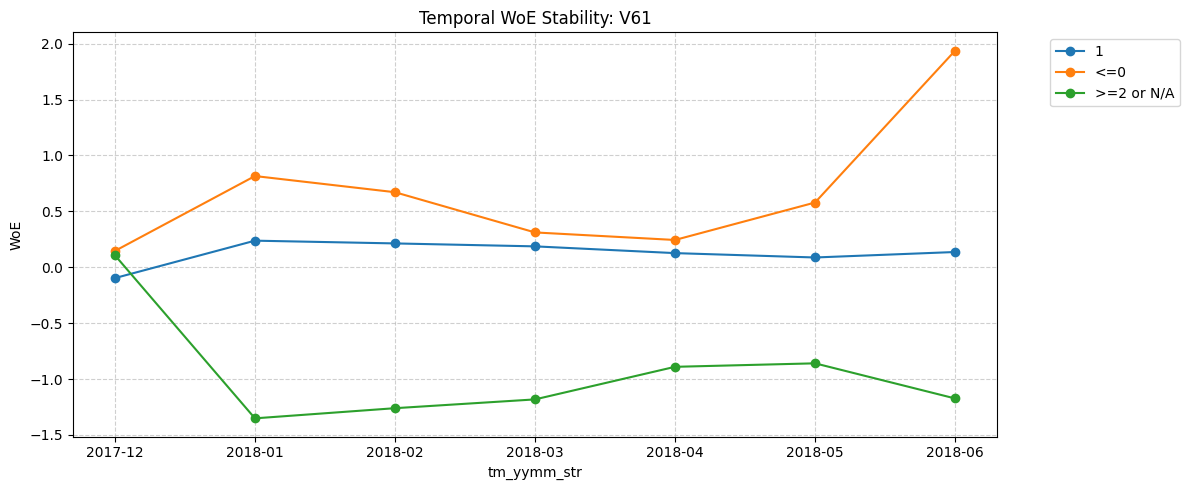

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V75,,,,,,,,
1,"5,630","259,452",0.2725,0.4553,0.4489,0.5133,0.0938,0.1467
2.0 or 3.0 or nan or 4.0 or 0.0,"15,033","310,425",0.7275,0.5447,0.5511,-0.2894,0.0529,0.1467
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1467,0.1467


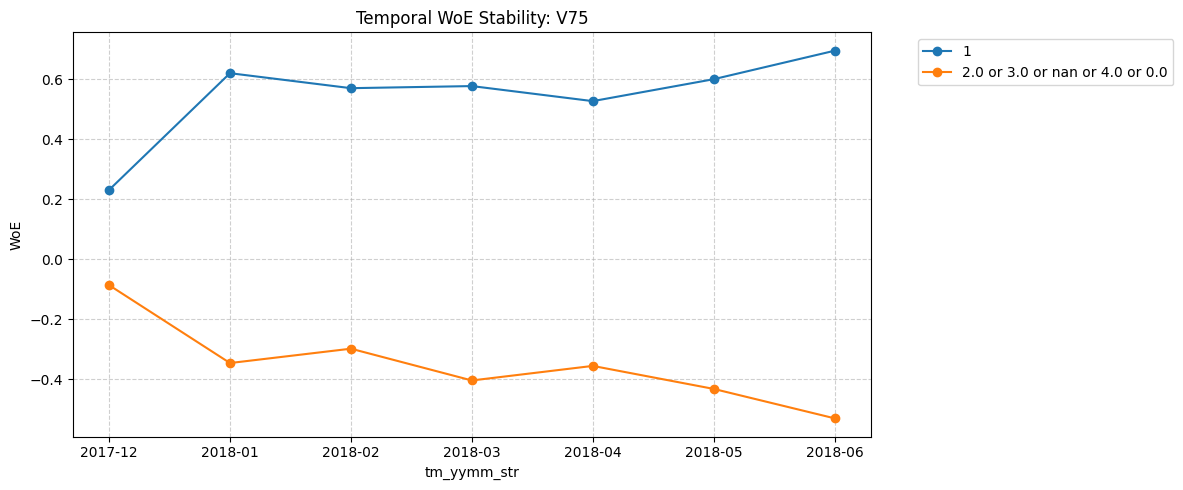

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V83,,,,,,,,
2 to 6,"2,003","19,040",0.0969,0.0334,0.0356,-1.0654,0.0677,0.0720
nan or 7.0 or 1.0 or 0.0,"18,660","550,837",0.9031,0.9666,0.9644,0.0680,0.0043,0.0720
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0720,0.0720


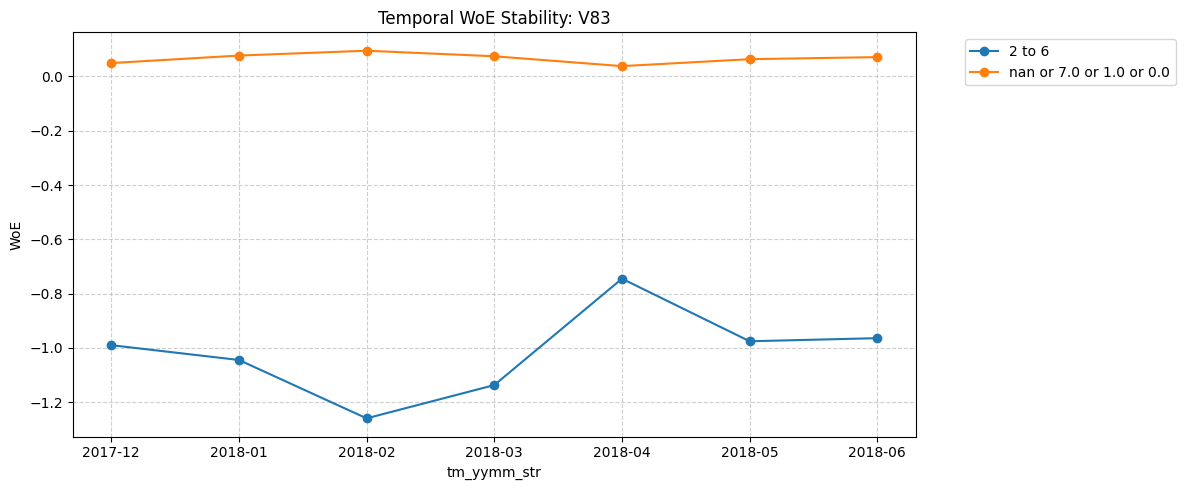

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
TransactionAmt_bin,,,,,,,,
"(-inf, 2.112] or (135.238, 150.442] or (150.442, inf] or (18.418, 18.663] or (18.663, 19.464] or (19.464, 24.893] or (2.112, 18.418]","9,325","174,495",0.4513,0.3062,0.3113,-0.3879,0.0563,0.0903
"(24.893, 135.238]","11,338","395,382",0.5487,0.6938,0.6887,0.2346,0.0340,0.0903
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0903,0.0903


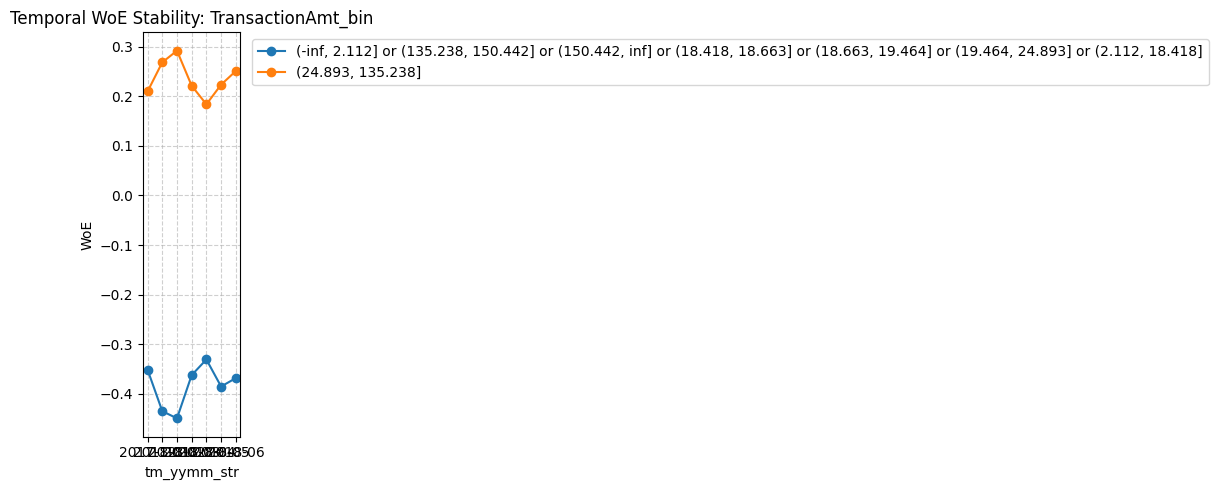

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
card2_bin,,,,,,,,
"(-inf, 175.5]","3,966","106,425",0.1919,0.1868,0.1869,-0.0275,0.0001,0.0666
"(175.5, 181.5]",678,"3,581",0.0328,0.0063,0.0072,-1.6534,0.0439,0.0666
"(181.5, 201.5] or (201.5, 499.5]","9,161","299,749",0.4434,0.5260,0.5231,0.1709,0.0141,0.0666
"(499.5, 500.5] or (500.5, 553.5] or (553.5, inf] or N/A","6,858","160,122",0.3319,0.2810,0.2828,-0.1666,0.0085,0.0666
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0666,0.0666


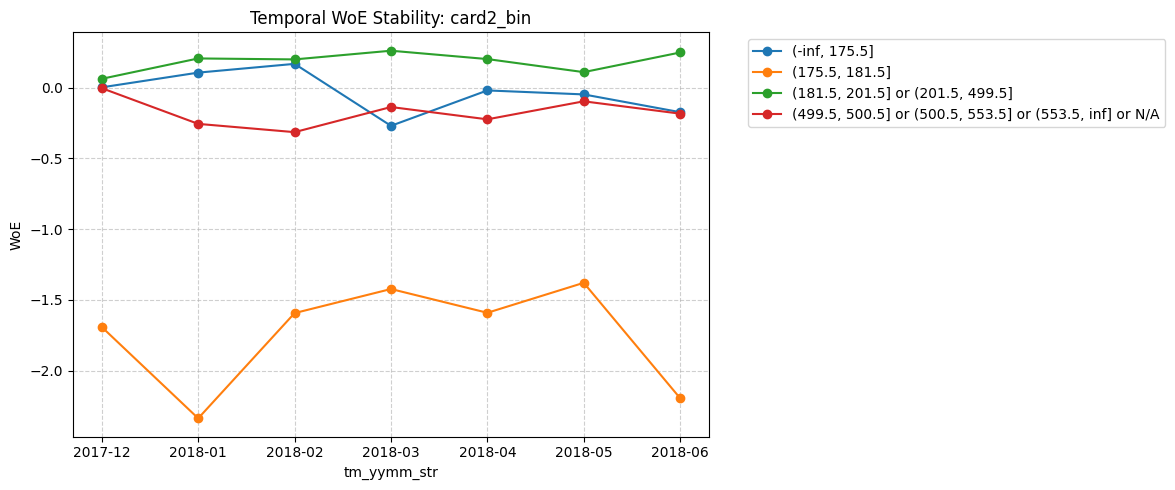

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
card3_bin,,,,,,,,
"(-inf, 118.5] or (118.5, 145.0] or (145.0, 149.5] or (149.5, 174.5]","13,183","517,618",0.6380,0.9083,0.8988,0.3532,0.0955,0.4666
"(174.5, 185.5] or (185.5, 213.5] or (213.5, inf] or N/A","7,480","52,259",0.3620,0.0917,0.1012,-1.3731,0.3712,0.4666
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.4666,0.4666


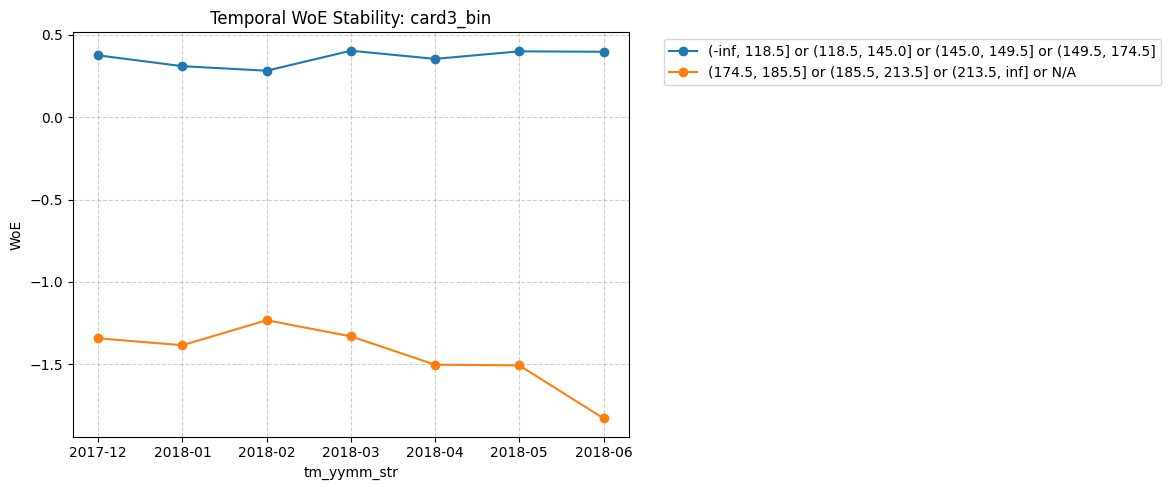

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
card5_bin,,,,,,,,
"(-inf, 108.0]","1,854","28,278",0.0897,0.0496,0.0510,-0.5926,0.0238,0.0255
"(108.0, 136.5] or (136.5, 137.5] or (137.5, 162.5] or (162.5, 168.0] or (168.0, 184.5] or (184.5, 224.5] or (224.5, inf] or N/A","18,809","541,599",0.9103,0.9504,0.9490,0.0431,0.0017,0.0255
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0255,0.0255


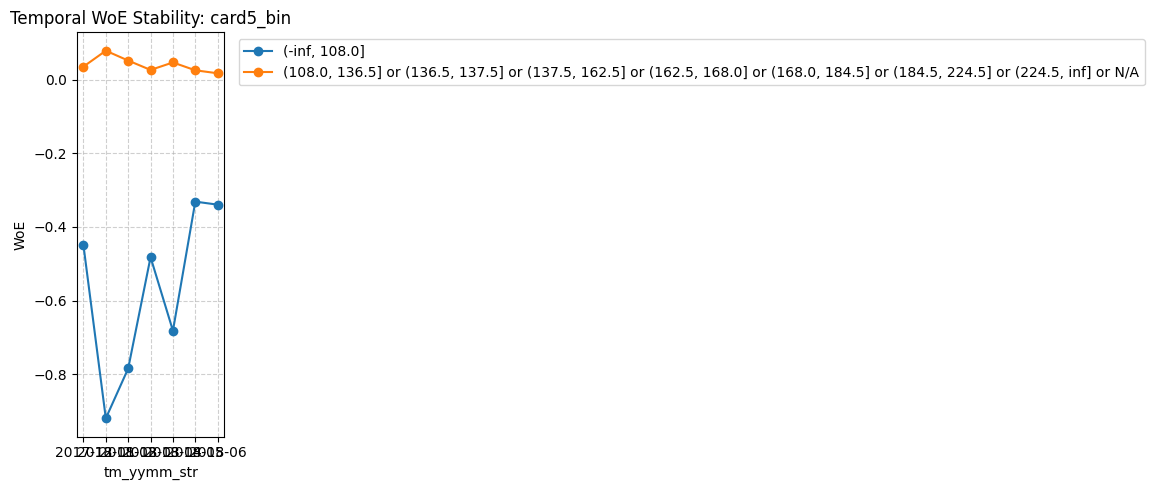

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
addr1_bin,,,,,,,,
"(-inf, 121.0]",64,"3,237",0.0031,0.0057,0.0056,0.5988,0.0015,0.4549
"(121.0, 122.5] or (122.5, 198.5] or (198.5, 535.5] or (535.5, inf]","12,858","508,675",0.6223,0.8926,0.8831,0.3608,0.0975,0.4549
N/A,"7,741","57,965",0.3746,0.1017,0.1113,-1.3038,0.3558,0.4549
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.4549,0.4549


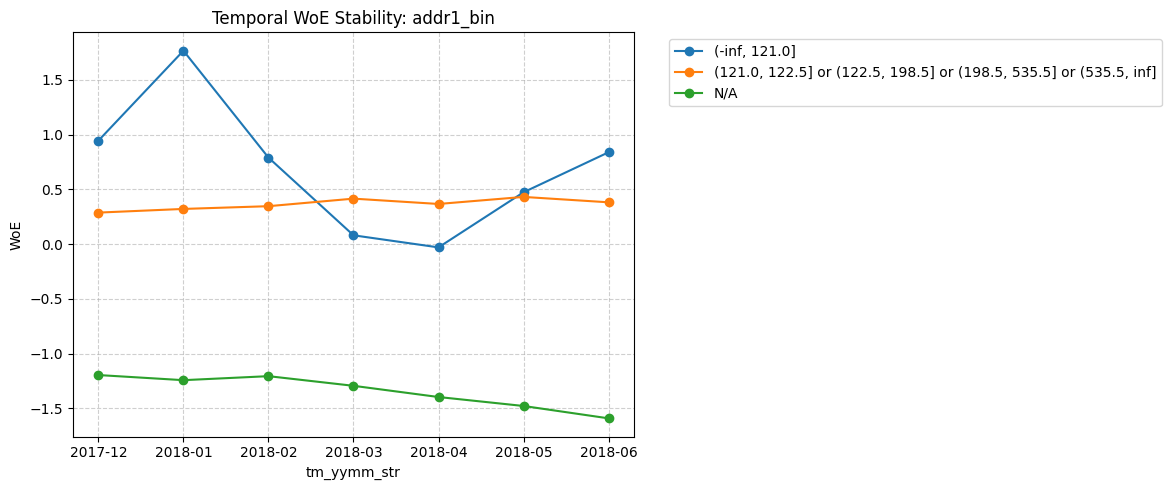

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
dist1_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 1.5] or (1.5, 3.5] or (1802.5, inf] or (3.5, 78.5] or (78.5, 958.5]","4,583","226,829",0.2218,0.3980,0.3919,0.5847,0.1030,0.1502
"(958.5, 976.5]",46,277,0.0022,0.0005,0.0005,-1.5307,0.0027,0.1502
"(976.5, 1802.5] or N/A","16,034","342,771",0.7760,0.6015,0.6076,-0.2547,0.0445,0.1502
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1502,0.1502


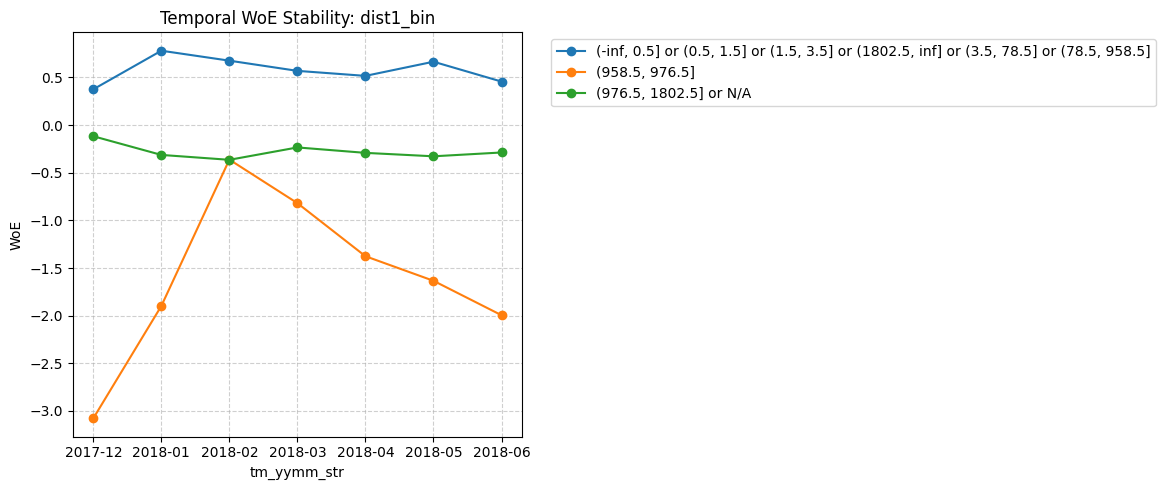

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
dist2_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 1.5]",732,"4,161",0.0354,0.0073,0.0083,-1.5799,0.0445,0.0453
"(1.5, 2.5] or (116.5, 1525.0] or (1525.0, inf] or (2.5, 116.5] or N/A","19,931","565,716",0.9646,0.9927,0.9917,0.0287,0.0008,0.0453
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0453,0.0453


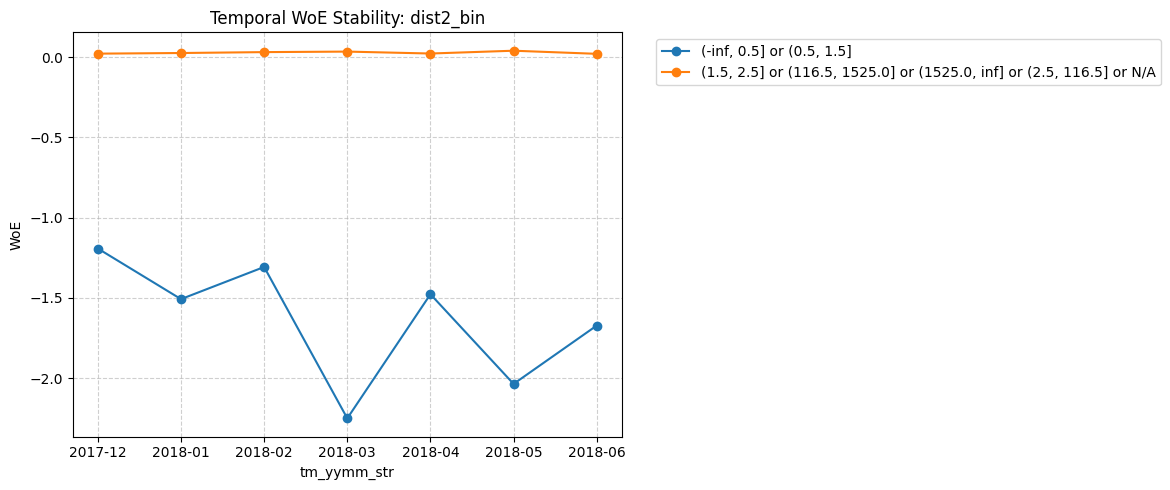

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
C2_bin,,,,,,,,
"(-inf, 1.5] or (1.5, 2.5]","10,644","410,008",0.5151,0.7195,0.7123,0.3341,0.0683,0.3191
"(187.5, 646.0]",619,"1,110",0.0300,0.0019,0.0029,-2.7334,0.0766,0.3191
"(2.5, 3.5]","1,872","49,898",0.0906,0.0876,0.0877,-0.0343,0.0001,0.3191
"(3.5, 9.5] or (646.0, inf] or (76.5, 187.5]","4,629","89,418",0.2240,0.1569,0.1593,-0.3562,0.0239,0.3191
"(9.5, 76.5]","2,899","19,443",0.1403,0.0341,0.0378,-1.4141,0.1502,0.3191
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.3191,0.3191


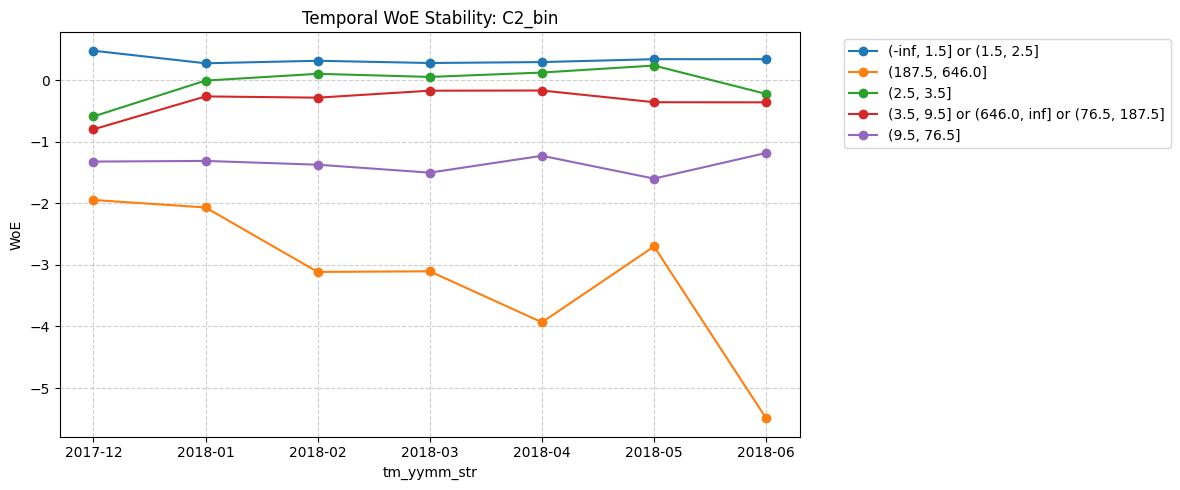

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
C6_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 1.5] or (1.5, 2.5] or (2.5, 3.5] or (3.5, 8.5] or (58.5, 859.5]","18,694","556,346",0.9047,0.9763,0.9738,0.0761,0.0054,0.1049
"(8.5, 58.5] or (859.5, inf]","1,969","13,531",0.0953,0.0237,0.0262,-1.3898,0.0995,0.1049
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1049,0.1049


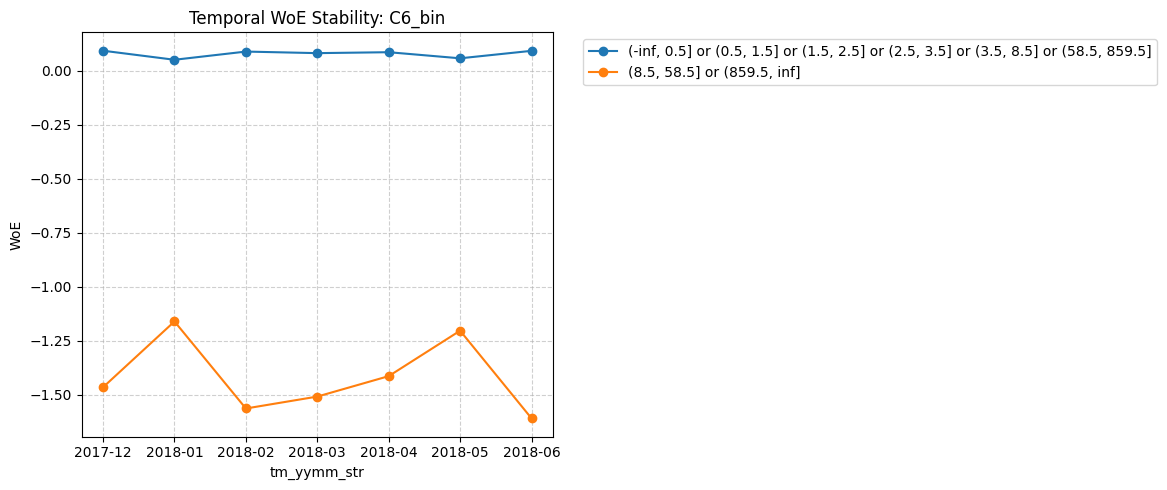

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
C10_bin,,,,,,,,
"(-inf, 0.5]","9,646","443,796",0.4668,0.7788,0.7678,0.5117,0.1596,0.6430
"(0.5, 1.5] or (1.5, 2.5]","6,276","108,893",0.3037,0.1911,0.1950,-0.4635,0.0522,0.6430
"(118.5, inf] or (2.5, 3.5]","1,085","7,650",0.0525,0.0134,0.0148,-1.3643,0.0534,0.6430
"(3.5, 6.5] or (6.5, 118.5]","3,656","9,538",0.1769,0.0167,0.0223,-2.3582,0.3778,0.6430
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.6430,0.6430


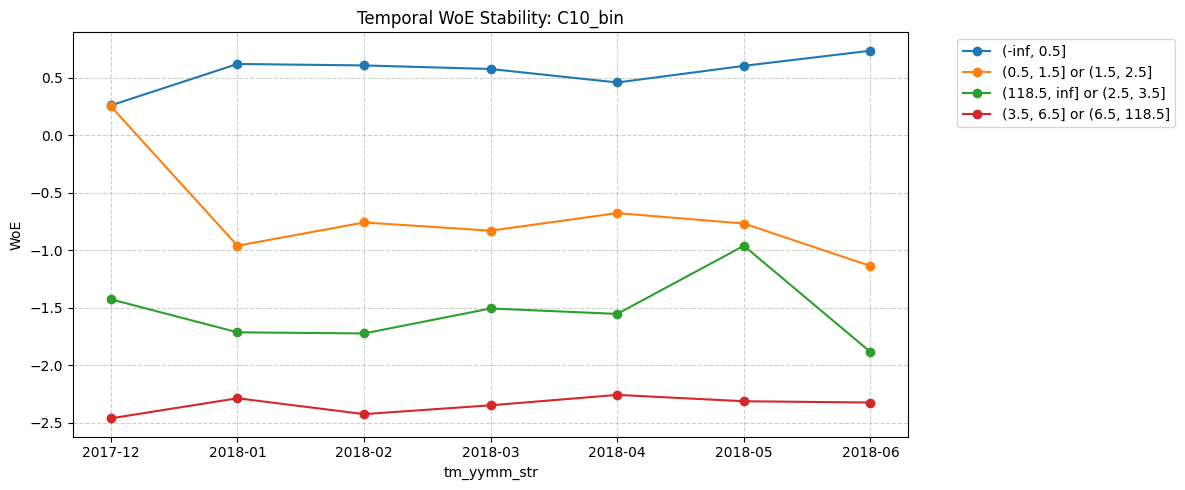

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
C11_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 1.5] or (1.5, 2.5]","13,625","467,608",0.6594,0.8205,0.8149,0.2186,0.0352,0.2111
"(125.5, inf] or (13.5, 52.5]","1,831","9,704",0.0886,0.0170,0.0195,-1.6496,0.1181,0.2111
"(2.5, 3.5] or (3.5, 13.5]","4,729","74,474",0.2289,0.1307,0.1341,-0.5604,0.0550,0.2111
"(52.5, 125.5]",478,"18,091",0.0231,0.0317,0.0314,0.3155,0.0027,0.2111
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2111,0.2111


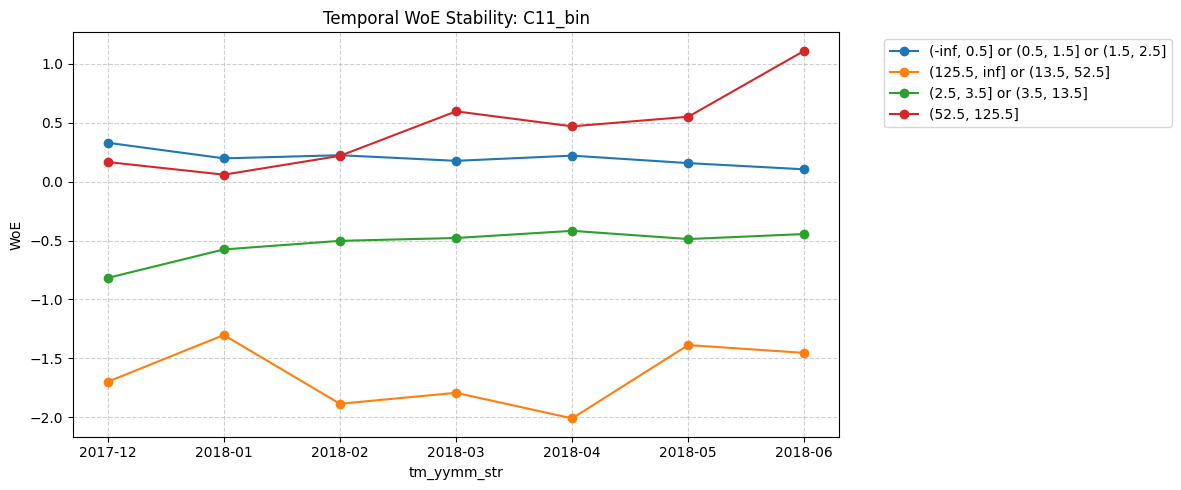

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
C12_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 1.5] or (1.5, 3.5]","17,277","565,010",0.8361,0.9915,0.9860,0.1704,0.0265,0.5817
"(11.5, 180.0]","1,843",535,0.0892,0.0009,0.0040,-4.5533,0.4019,0.5817
"(180.0, 644.5] or (3.5, 11.5] or (644.5, inf]","1,543","4,332",0.0747,0.0076,0.0099,-2.2850,0.1533,0.5817
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.5817,0.5817


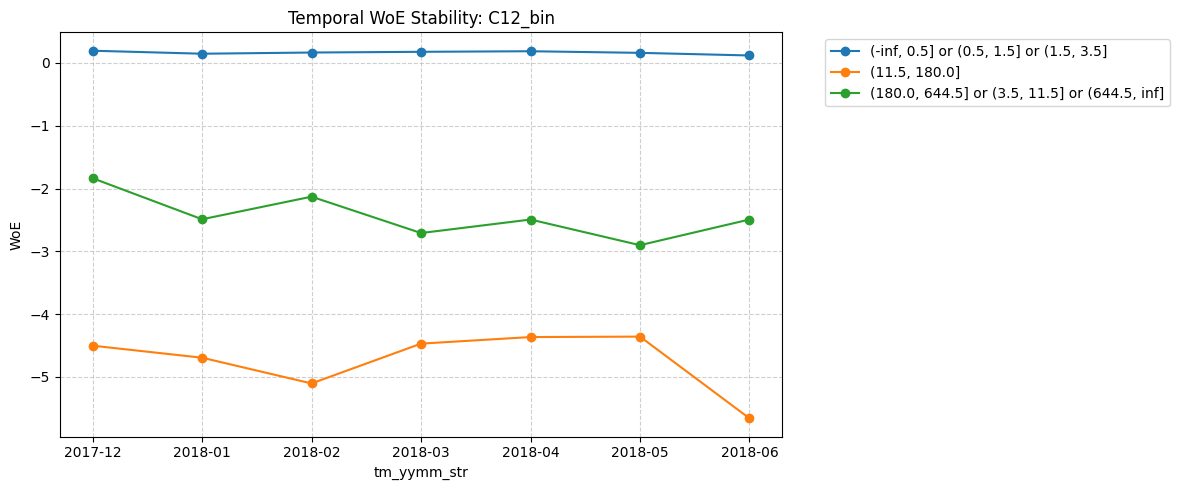

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D1_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 3.5]","13,786","283,901",0.6672,0.4982,0.5041,-0.2921,0.0494,0.1734
"(202.5, 555.5]","1,185","93,145",0.0573,0.1634,0.1597,1.0469,0.1111,0.1734
"(26.5, 33.5] or (3.5, 26.5] or (33.5, 202.5] or (555.5, inf] or N/A","5,692","192,831",0.2755,0.3384,0.3362,0.2056,0.0129,0.1734
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1734,0.1734


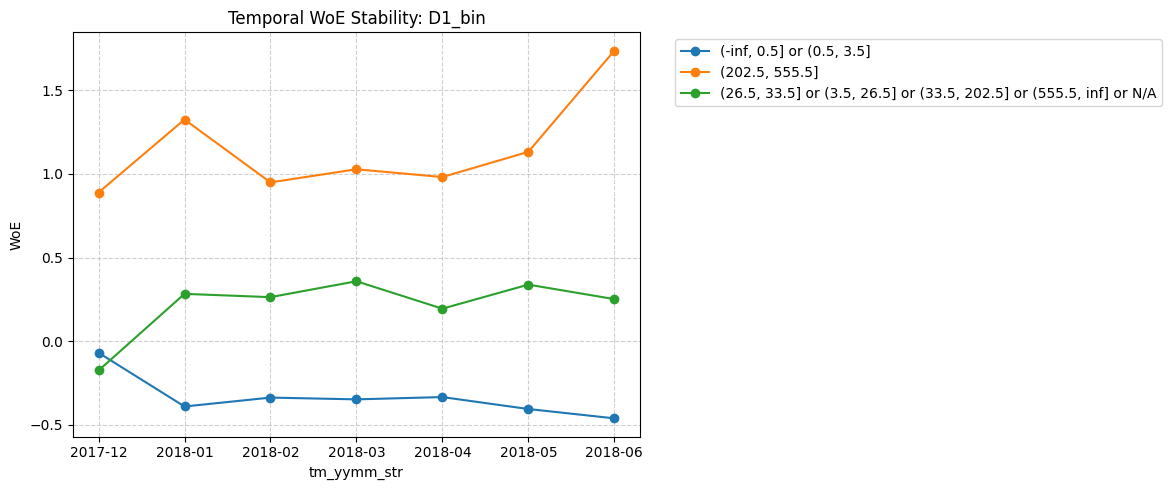

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D2_bin,,,,,,,,
"(-inf, 0.5]",935,"14,189",0.0452,0.0249,0.0256,-0.5979,0.0122,0.1732
"(0.5, 3.5]","1,534","13,251",0.0742,0.0233,0.0250,-1.1611,0.0592,0.1732
"(11.5, 33.5] or (256.5, inf]","1,921","121,097",0.0930,0.2125,0.2083,0.8264,0.0988,0.1732
"(3.5, 6.5] or (33.5, 256.5] or (6.5, 11.5] or N/A","16,273","421,340",0.7875,0.7394,0.7410,-0.0631,0.0030,0.1732
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1732,0.1732


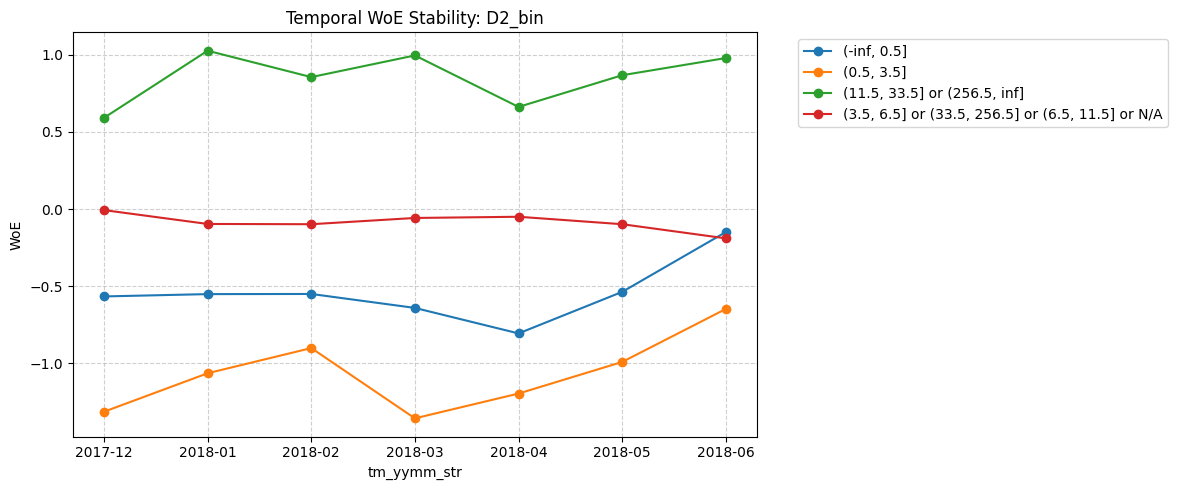

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D4_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 5.5]","8,498","173,886",0.4113,0.3051,0.3088,-0.2985,0.0317,0.0574
"(27.5, 282.5] or (282.5, 284.5] or (284.5, 559.5] or (5.5, 27.5]","5,969","216,494",0.2889,0.3799,0.3767,0.2738,0.0249,0.0574
"(559.5, inf] or N/A","6,196","179,497",0.2999,0.3150,0.3144,0.0491,0.0007,0.0574
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0574,0.0574


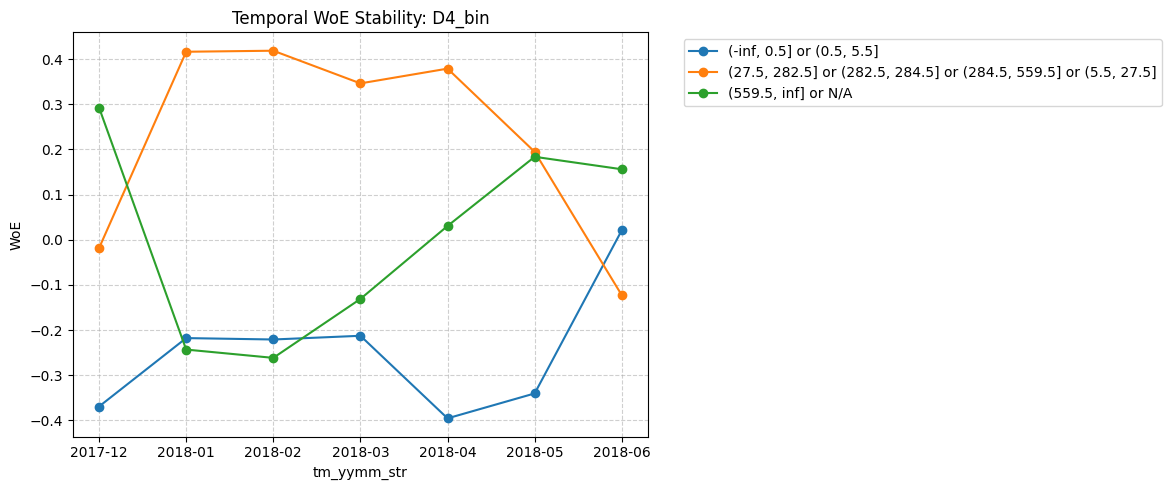

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D8_bin,,,,,,,,
"(-inf, 0.979]","3,288","15,555",0.1591,0.0273,0.0319,-1.7631,0.2325,0.4827
"(0.979, 5.354]","1,211","4,147",0.0586,0.0073,0.0091,-2.0864,0.1071,0.4827
"(1155.896, inf] or (129.271, 1155.896] or (29.937, 30.521] or (30.521, 42.812] or (42.812, 129.271] or (5.354, 29.937]","3,328","47,397",0.1611,0.0832,0.0859,-0.6610,0.0515,0.4827
N/A,"12,836","502,778",0.6212,0.8823,0.8731,0.3508,0.0916,0.4827
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.4827,0.4827


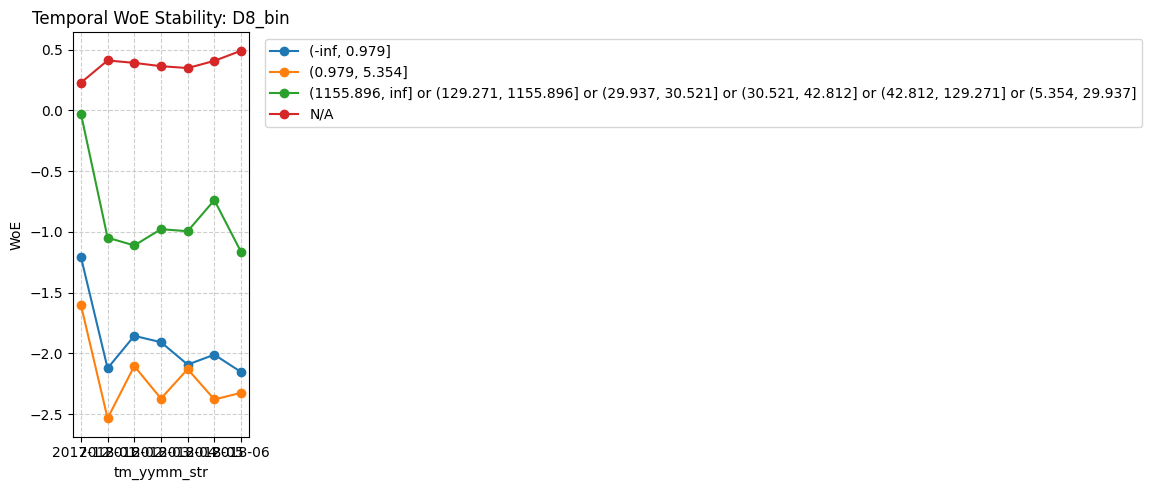

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D9_bin,,,,,,,,
"(-inf, 0.146] or (0.146, 0.229] or (0.229, 0.437] or (0.437, 0.479]","3,298","20,028",0.1596,0.0351,0.0395,-1.5134,0.1884,0.4133
"(0.479, 0.521] or (0.521, 0.687] or (0.687, 0.937] or (0.937, inf]","4,529","47,071",0.2192,0.0826,0.0874,-0.9760,0.1333,0.4133
N/A,"12,836","502,778",0.6212,0.8823,0.8731,0.3508,0.0916,0.4133
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.4133,0.4133


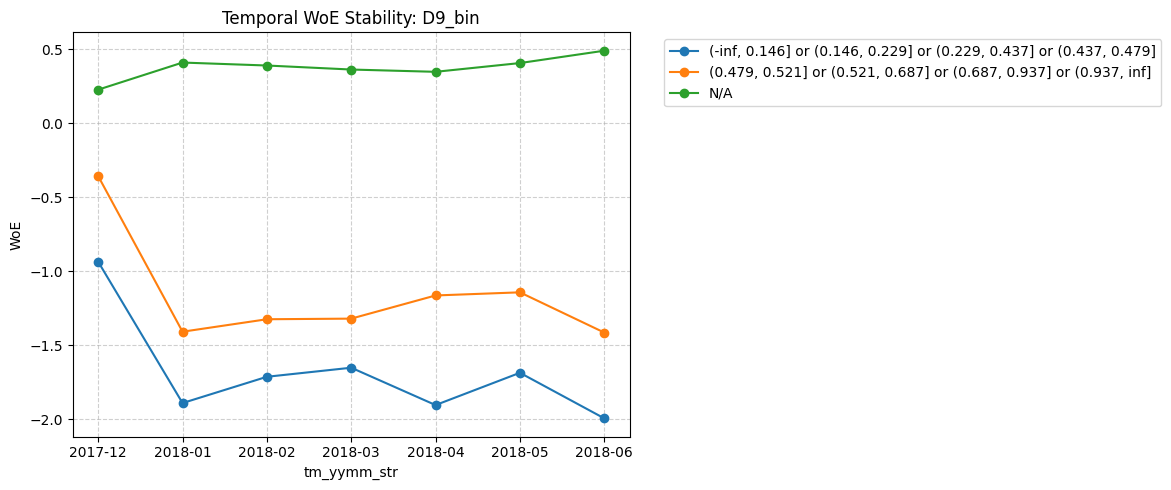

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D10_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 2.5] or (13.5, 25.5] or (2.5, 13.5]","13,057","259,223",0.6319,0.4549,0.4611,-0.3287,0.0582,0.1563
"(25.5, 50.5] or (464.5, inf]","1,180","79,164",0.0571,0.1389,0.1361,0.8885,0.0727,0.1563
"(50.5, 464.5] or N/A","6,426","231,490",0.3110,0.4062,0.4029,0.2671,0.0254,0.1563
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1563,0.1563


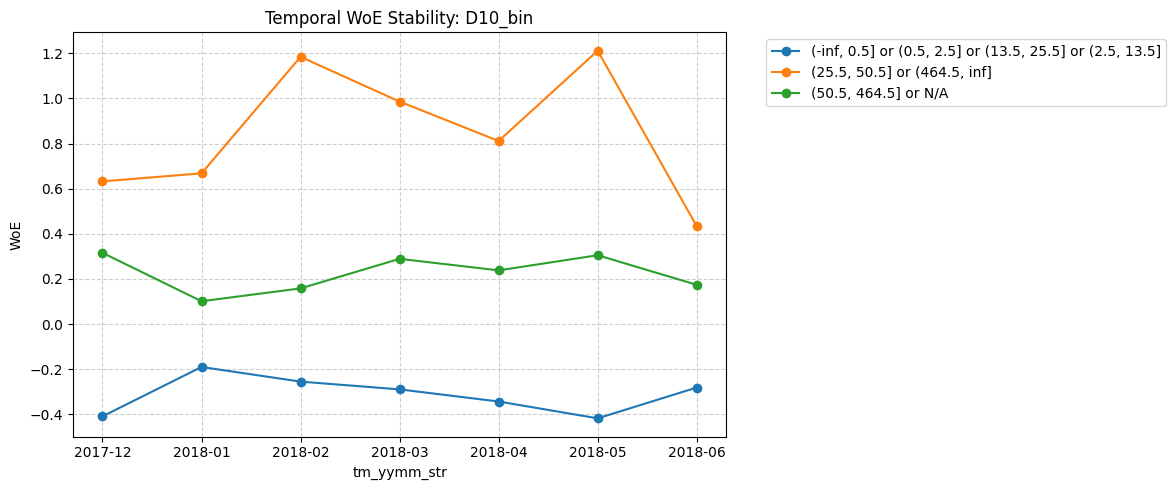

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D11_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 6.5] or (104.5, 127.5] or (127.5, 367.5] or (367.5, 397.5] or (397.5, inf] or (6.5, 104.5]","6,106","305,147",0.2955,0.5355,0.5271,0.5944,0.1426,0.2426
N/A,"14,557","264,730",0.7045,0.4645,0.4729,-0.4164,0.0999,0.2426
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2426,0.2426


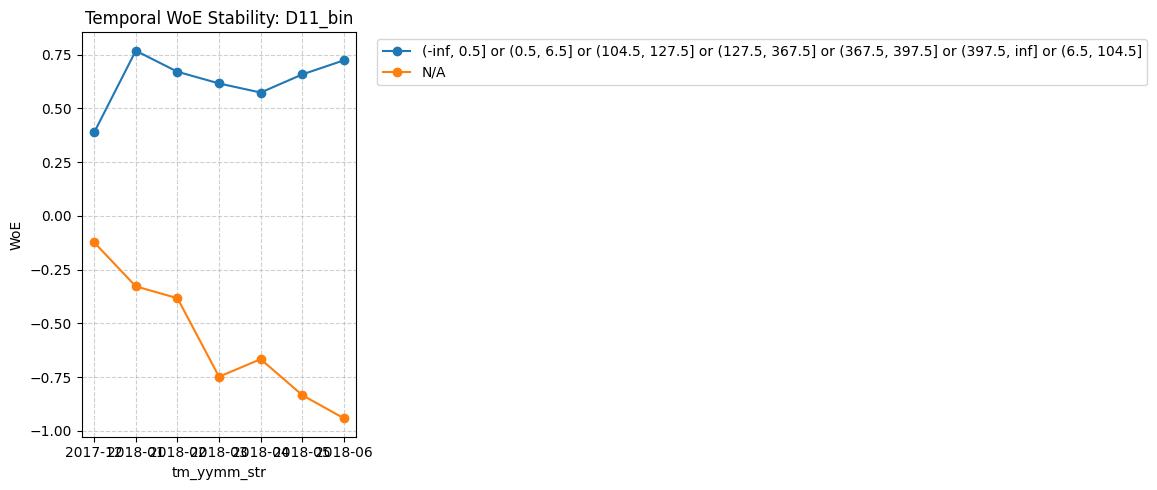

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D15_bin,,,,,,,,
"(-inf, 0.5]","7,886","166,375",0.3816,0.2919,0.2951,-0.2680,0.0240,0.1900
"(0.5, 3.5]","1,421","11,084",0.0688,0.0194,0.0212,-1.2632,0.0623,0.1900
"(198.5, 548.5]","2,199","134,633",0.1064,0.2362,0.2317,0.7973,0.1035,0.1900
"(27.5, 71.5] or (3.5, 27.5] or (548.5, inf] or (71.5, 198.5] or N/A","9,157","257,785",0.4432,0.4524,0.4520,0.0205,0.0002,0.1900
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1900,0.1900


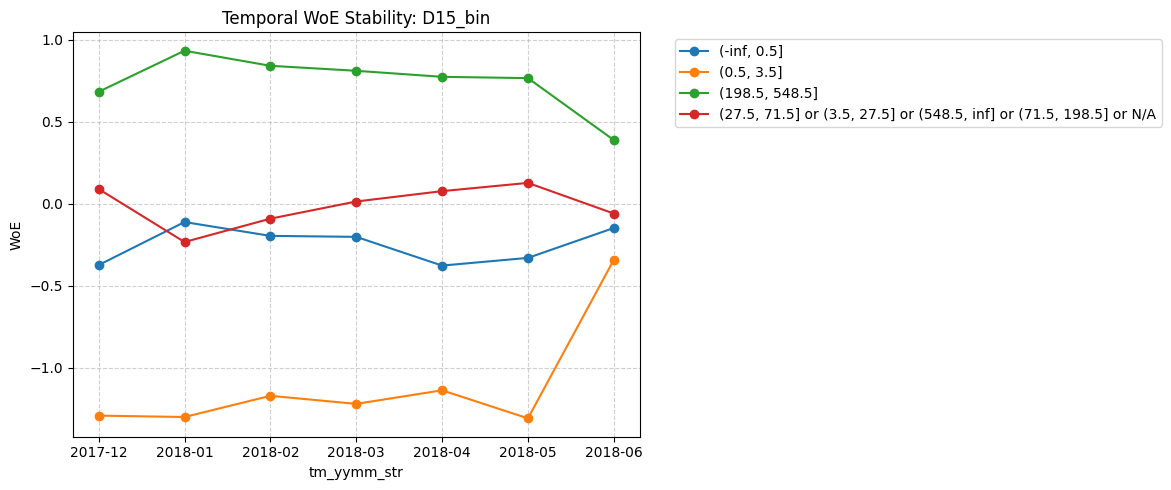

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V78_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 1.5]","11,983","446,503",0.5799,0.7835,0.7764,0.3009,0.0612,0.2477
"(1.5, 2.5] or (11.5, inf] or (2.5, 3.5] or (3.5, 5.5] or (5.5, 11.5]","4,404","38,486",0.2131,0.0675,0.0726,-1.1494,0.1674,0.2477
N/A,"4,276","84,888",0.2069,0.1490,0.1510,-0.3288,0.0191,0.2477
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2477,0.2477


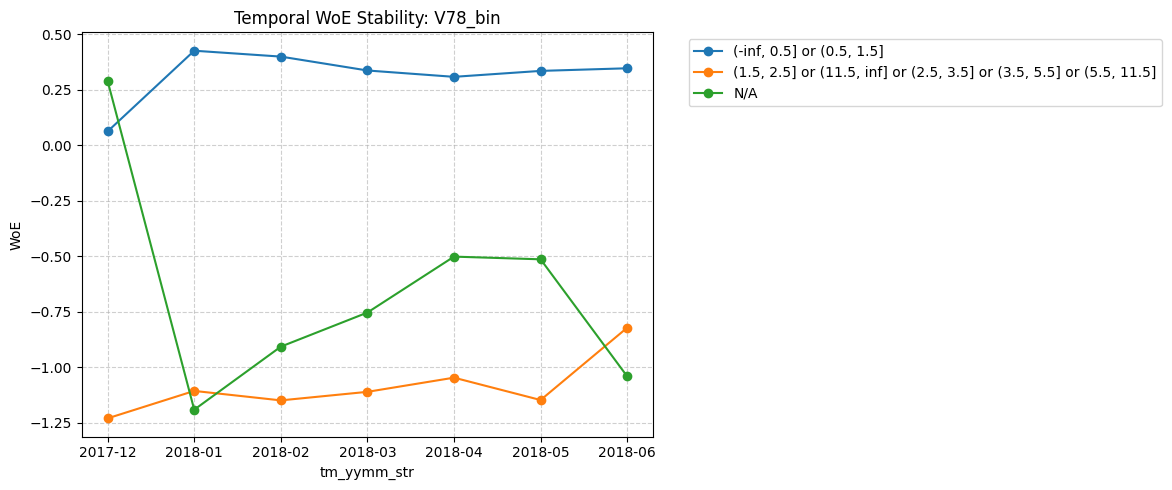

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V86_bin,,,,,,,,
"(-inf, 0.5] or (0.5, 1.5]","12,339","465,299",0.5972,0.8165,0.8088,0.3128,0.0686,0.4303
"(1.5, 2.5]","1,862","17,665",0.0901,0.0310,0.0331,-1.0674,0.0631,0.4303
"(2.5, 3.5] or (3.5, 6.5]","1,779","1,964",0.0861,0.0034,0.0063,-3.2181,0.2660,0.4303
"(6.5, inf] or N/A","4,683","84,949",0.2266,0.1491,0.1518,-0.4190,0.0325,0.4303
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.4303,0.4303


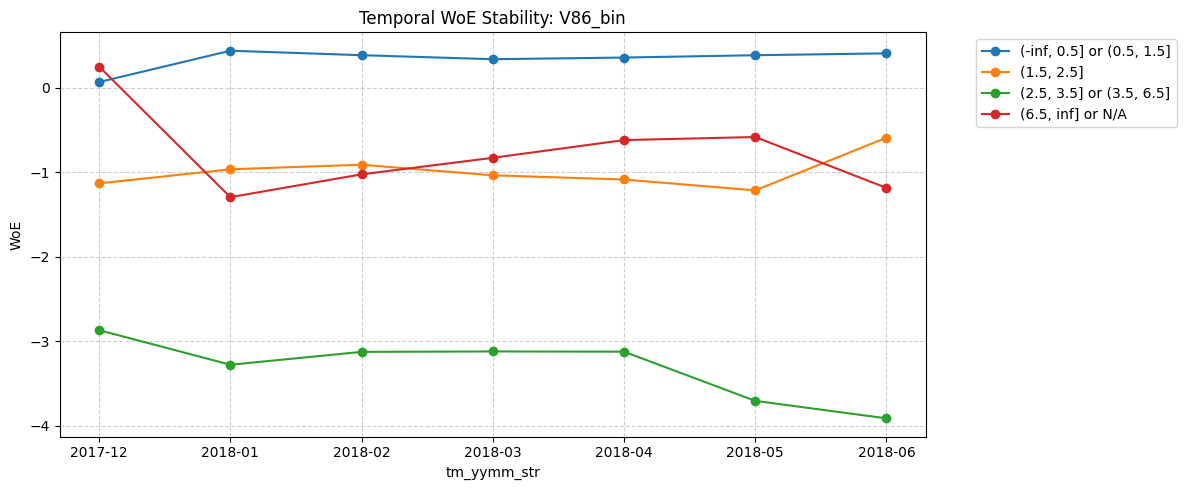

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V282_bin,,,,,,,,
"(-inf, 0.5]","3,557","209,255",0.1721,0.3672,0.3604,0.7574,0.1477,0.2868
"(0.5, 1.5]","12,020","304,435",0.5817,0.5342,0.5359,-0.0852,0.0040,0.2868
"(1.5, 2.5] or (2.5, 4.5] or (4.5, 8.5] or (8.5, inf] or N/A","5,086","56,187",0.2461,0.0986,0.1038,-0.9149,0.1350,0.2868
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2868,0.2868


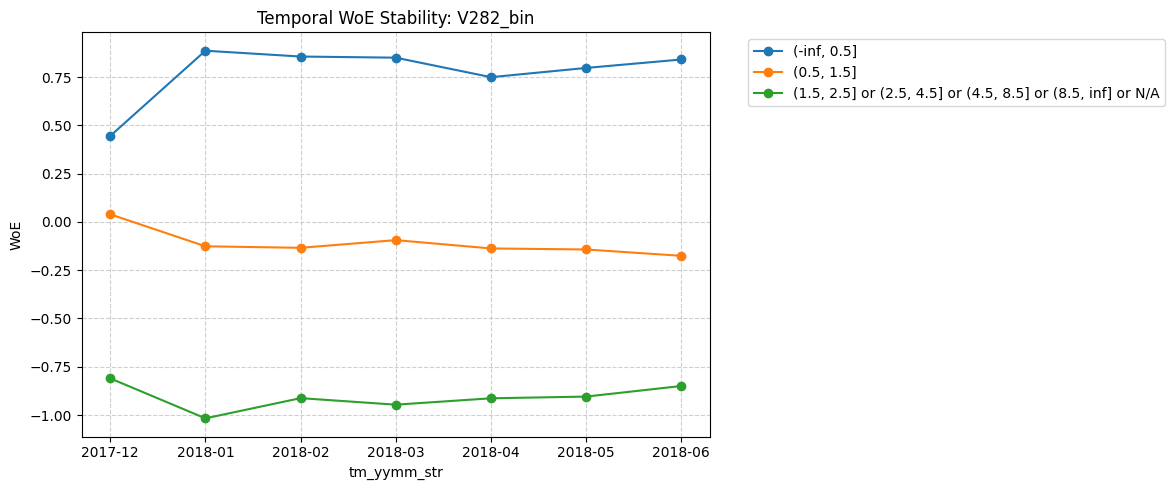

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V283_bin,,,,,,,,
"(-inf, 0.5]","3,521","207,978",0.1704,0.3650,0.3581,0.7615,0.1481,0.2778
"(0.5, 1.5] or (1.5, 3.5]","14,498","340,858",0.7016,0.5981,0.6017,-0.1596,0.0165,0.2778
"(10.5, 20.5] or (20.5, inf] or (3.5, 10.5] or N/A","2,644","21,041",0.1280,0.0369,0.0401,-1.2430,0.1132,0.2778
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2778,0.2778


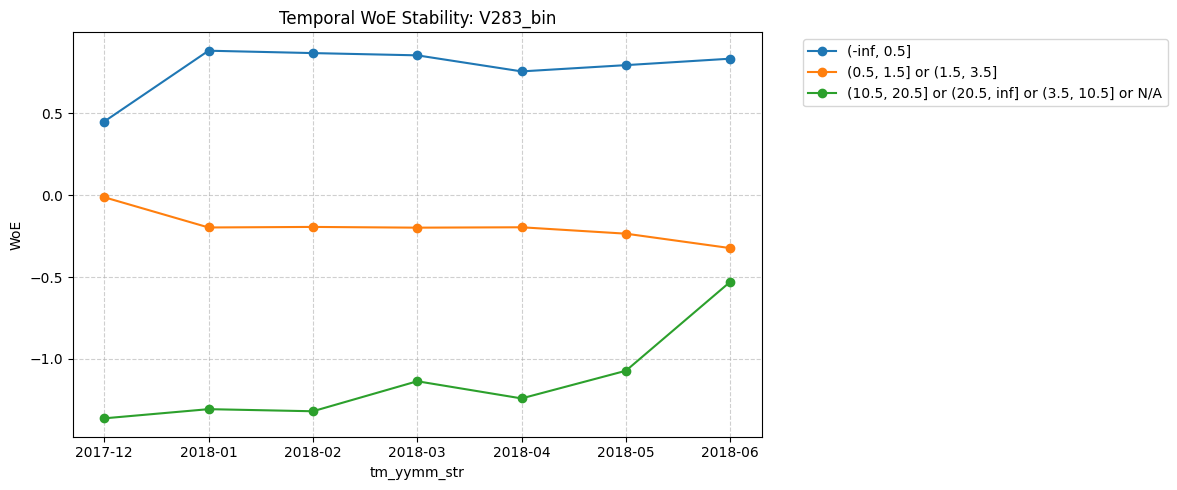

📊 Information Value Table (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V307_bin,,,,,,,,
"(-inf, 47.611]","11,482","335,011",0.5557,0.5879,0.5867,0.0563,0.0018,0.0042
"(1940.25, 4475.0] or (342.817, 444.985] or (444.985, 788.995] or (4475.0, 57061.842] or (47.611, 342.817] or (57061.842, inf] or (788.995, 1940.25] or N/A","9,181","234,866",0.4443,0.4121,0.4133,-0.0752,0.0024,0.0042
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0042,0.0042


/Users/cristianooliveira/Documents/model-track-cr/src/model_track/woe/stability.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


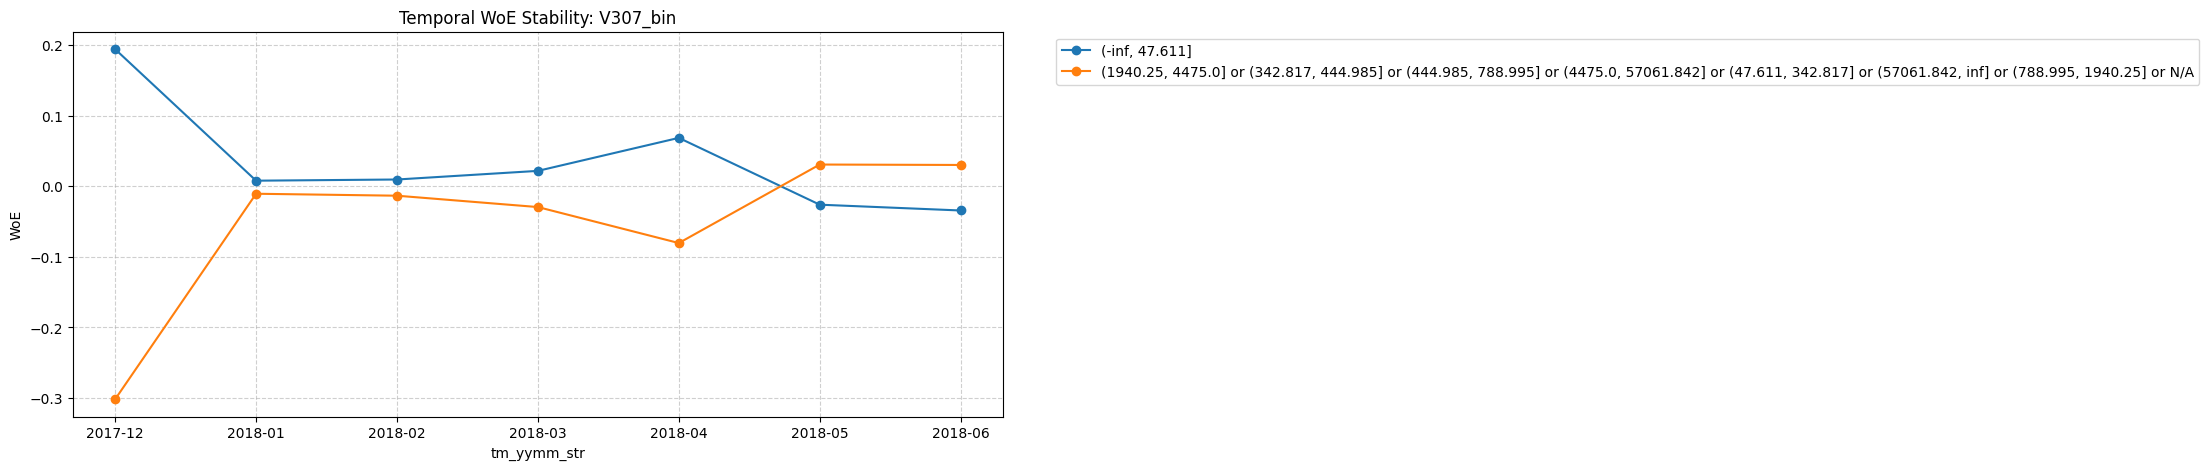

In [21]:
# %% [NB Step 10] Full Evaluation: WoE Table and Stability Charts
from IPython.display import HTML, display

from model_track.woe.stability import WoeStability


def generate_global_woe_table(df, feature, target):
    """Generates the classic WoE/IV analytical table for a variable."""

    # 1. Basic counts
    stats = (
        df.groupby(feature, observed=True)[target]
        .agg(["count", "sum"])
        .rename(columns={"count": "exposure_count", "sum": "n_event"})
    )
    stats["n_non_event"] = stats["exposure_count"] - stats["n_event"]

    total_events = stats["n_event"].sum()
    total_non_events = stats["n_non_event"].sum()
    total_count = stats["exposure_count"].sum()

    # 2. Real rates (For display in the table)
    stats["event_rate"] = stats["n_event"] / total_events
    stats["non_event_rate"] = stats["n_non_event"] / total_non_events
    stats["exposure"] = stats["exposure_count"] / total_count

    # 3. Smoothed rates with Laplace (For mathematical calculation without div/0 errors)
    sm_event = (stats["n_event"] + 0.5) / (total_events + 0.5)
    sm_non_event = (stats["n_non_event"] + 0.5) / (total_non_events + 0.5)

    # WoE and IV calculation (Convention: ln(Good/Bad))
    stats["woe"] = np.log(sm_non_event / sm_event)
    stats["iv"] = (sm_non_event - sm_event) * stats["woe"]
    stats["iv_total"] = stats["iv"].sum()

    # 4. Selection and sorting
    cols = [
        "n_event",
        "n_non_event",
        "event_rate",
        "non_event_rate",
        "exposure",
        "woe",
        "iv",
        "iv_total",
    ]
    woe_table = stats[cols].copy()

    # 5. Add TOTAL row
    woe_table.loc["__TOTAL__"] = [
        total_events,
        total_non_events,
        woe_table["event_rate"].sum(),
        woe_table["non_event_rate"].sum(),
        woe_table["exposure"].sum(),
        np.nan,  # WoE for total doesn't make sense
        woe_table["iv"].sum(),
        woe_table["iv_total"].iloc[0],
    ]

    return woe_table


# Initialize stability class
ws = WoeStability(date_col="tm_yymm_str")

print(f"🔍 Starting audit for {len(dict_joined_categories)} variables...\n")

# Loop through all grouped features
for col_var in dict_joined_categories.keys():
    # Visual break in Jupyter to separate each variable
    display(HTML(f"<hr><h3 style='color: #2c3e50;'>Variable: <b>{col_var}</b></h3>"))

    # --- 1. GLOBAL WOE TABLE ---
    analytical_table = generate_global_woe_table(df_train, col_var, "isFraud")

    # Formatting for readability (4 decimal places where applicable)
    formatted_table = analytical_table.style.format(
        {
            "n_event": "{:,.0f}",
            "n_non_event": "{:,.0f}",
            "event_rate": "{:.4f}",
            "non_event_rate": "{:.4f}",
            "exposure": "{:.4f}",
            "woe": "{:.4f}",
            "iv": "{:.4f}",
            "iv_total": "{:.4f}",
        }
    ).background_gradient(subset=["woe"], cmap="coolwarm")

    print("📊 Information Value Table (Global):")
    display(formatted_table)

    # --- 2. STABILITY PLOT ---
    stability_matrix = ws.calculate_stability_matrix(
        df_train, feature_col=col_var, target_col="isFraud"
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ws.generate_view(matrix=stability_matrix, title=f"Temporal WoE Stability: {col_var}", ax=ax)
    plt.show()

In [22]:
import gc

import pandas as pd


class WoeCalculator:
    @staticmethod
    def preprocess_categories(df, columns):
        """Handles nulls and converts to string for mapping consistency."""
        df_new = df.copy()
        for col in columns:
            df_new[col] = df_new[col].astype(str).replace(["nan", "None", "nan", "null", ""], "N/A")
        return df_new

    @staticmethod
    def compute_mapping(df, target_col, feature_col):
        """Generates the WoE map with Laplace adjustment."""
        stats = df.groupby(feature_col, observed=True)[target_col].agg(["count", "sum"])
        stats.columns = ["Total", "Bad"]
        stats["Good"] = stats["Total"] - stats["Bad"]

        # Laplace adjustment to avoid log(0)
        perc_bad = (stats["Bad"] + 0.5) / (stats["Bad"].sum() + 0.5)
        perc_good = (stats["Good"] + 0.5) / (stats["Good"].sum() + 0.5)

        # ln(%Good / %Bad)
        return np.log(perc_good / perc_bad).to_dict()


# --- WoE Pipeline Execution ---

# 1. Prior Null Handling (Ensures 'N/A')
df_train = WoeCalculator.preprocess_categories(df_train, top_features)
df_test = WoeCalculator.preprocess_categories(df_test, top_features)

all_woe_maps = {}
new_woe_cols_train = {}
new_woe_cols_test = {}

print(f"🧪 Fitting WoE on 'dev' for {len(top_features)} features...")

for col in top_features:
    # FIT: Only on the Development sample
    df_dev_temp = df_train.query("Sample == 'dev'")
    mapping = WoeCalculator.compute_mapping(df_dev_temp, "isFraud", col)
    all_woe_maps[col] = mapping

    # TRANSFORM: Apply to Train and Test
    # .get(val, 0.0) ensures new categories (OOT/Test) receive WoE 0
    new_col_name = f"{col}_woe"
    new_woe_cols_train[new_col_name] = df_train[col].map(mapping).fillna(0.0)
    new_woe_cols_test[new_col_name] = df_test[col].map(mapping).fillna(0.0)

# 2. Final Concatenation (Anti-Fragmentation)
df_train = pd.concat([df_train, pd.DataFrame(new_woe_cols_train, index=df_train.index)], axis=1)
df_test = pd.concat([df_test, pd.DataFrame(new_woe_cols_test, index=df_test.index)], axis=1)

# Cleaning
del new_woe_cols_train, new_woe_cols_test
gc.collect()

print("✅ WoE applied successfully. Categories not seen in 'dev' mapped to 0.0.")

🧪 Fitting WoE on 'dev' for 30 features...
✅ WoE applied successfully. Categories not seen in 'dev' mapped to 0.0.


In [23]:
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression

# Final features (WoE fields only)
final_features = [f"{c}_woe" for c in top_features]

# Sample filter
X_dev = df_train.query("Sample == 'dev'")[final_features]
y_dev = df_train.query("Sample == 'dev'")["isFraud"]

X_oot = df_train.query("Sample == 'oot'")[final_features]
y_oot = df_train.query("Sample == 'oot'")["isFraud"]

# 1. Model Fitting
lr_model = LogisticRegression(class_weight="balanced", solver="lbfgs", max_iter=1000)
lr_model.fit(X_dev, y_dev)

# 2. Probabilistic Prediction
df_train["proba"] = lr_model.predict_proba(df_train[final_features])[:, 1]


# 3. KS Calculation by Period
def calculate_metrics(data):
    # AUC
    auc = roc_auc_score(data["isFraud"], data["proba"])
    # KS (Maximum distance between cumulative distribution of goods and bads)
    bads = data.loc[data["isFraud"] == 1, "proba"]
    goods = data.loc[data["isFraud"] == 0, "proba"]
    ks = ks_2samp(bads, goods).statistic
    return pd.Series({"AUC": auc, "KS": ks})


performance_summary = df_train.groupby("tm_yymm_str").apply(calculate_metrics).reset_index()

print("\n🏆 PERFORMANCE BY MONTH (FINAL MODEL):")
display(performance_summary)


🏆 PERFORMANCE BY MONTH (FINAL MODEL):


/var/folders/0m/mtf6psc91_l02bjt_n2nd7bh0000gn/T/ipykernel_60949/289293977.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  performance_summary = df_train.groupby("tm_yymm_str").apply(calculate_metrics).reset_index()


,tm_yymm_str,AUC,KS
0,2017-12,0.788352,0.452108
1,2018-01,0.831647,0.529078
2,2018-02,0.838631,0.542604
3,2018-03,0.819424,0.504680
4,2018-04,0.808000,0.479864
5,2018-05,0.799641,0.471446
6,2018-06,0.792494,0.488262


### 📘 How to read this Table to conclude your reasoning:

1.  **Focus on Capture (Recall):** If your boss asks: "Cristiano, how do we catch **50% of next month's frauds**?", you look at the 50% row.
2.  **Decline Cost (FPR/Volume Impact):** In the second column, you'll see the impact. Example: If it's 3%, you say: "We need to decline **3% of total order volume** to stop half of the frauds."
3.  **Hit Rate (Precision):** This column is vital. If it's at 40%, it means that for every 10 orders you blocked to reach this target, 4 were actual frauds and 6 were good customers who were impacted (False Positives).
4.  **Cutoff Point (Threshold):** This is the value from 0 to 1 that you will configure in the approval system.

In [24]:
import pandas as pd


def generate_fraud_capture_table(df, target_col, proba_col):
    """
    Generates a table focused on: To catch X% of frauds, how much of the total do I decline?
    """
    # 1. Sort by descending score
    df_sorted = (
        df[[target_col, proba_col]]
        .sort_values(by=proba_col, ascending=False)
        .reset_index(drop=True)
    )

    total_frauds = df_sorted[target_col].sum()
    total_orders = len(df_sorted)

    # 2. Cumulative calculations
    df_sorted["cumulative_frauds_caught"] = df_sorted[target_col].cumsum()
    df_sorted["tpr_acum"] = df_sorted["cumulative_frauds_caught"] / total_frauds

    # 3. Desired capture levels (how much fraud we want to catch)
    target_capture = [
        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
        0.30,
        0.35,
        0.40,
        0.45,
        0.50,
        0.60,
        0.70,
        0.80,
        0.90,
    ]

    rows = []
    for target in target_capture:
        # Find the first record where cumulative capture reaches the target
        idx = (df_sorted["tpr_acum"] >= target).idxmax()
        record = df_sorted.iloc[idx]

        # How many cumulative orders up to this point?
        declined_orders_count = idx + 1
        total_orders_pct = (declined_orders_count / total_orders) * 100

        # Secondary metrics
        actual_tpr = record["tpr_acum"] * 100
        fnr = 100 - actual_tpr  # What escaped from total fraud
        cutoff = record[proba_col]

        # Precision (Hit Rate): Of everything declined at this level, how much was fraud?
        hit_rate = (record["cumulative_frauds_caught"] / declined_orders_count) * 100

        rows.append(
            {
                "Target Capture (Total Fraud %)": int(target * 100),
                "Total Orders Declined (%)": round(total_orders_pct, 2),
                "Actual True Positive Rate (%)": round(actual_tpr, 2),
                "False Negative Rate (%)": round(fnr, 2),
                "Hit Rate (Precision %)": round(hit_rate, 2),
                "Cutoff Point (Score)": round(cutoff, 4),
            }
        )

    return pd.DataFrame(rows)


# Generating the table for the OOT Sample (Temporal Validation)
df_oot = df_train.query("Sample == 'oot'").copy()
decision_table = generate_fraud_capture_table(df_oot, "isFraud", "proba")

print("🛡️ FRAUD CAPTURE STRATEGY (OOT):")
display(decision_table)

🛡️ FRAUD CAPTURE STRATEGY (OOT):


,Target Capture (Total Fraud %),Total Orders Declined (%),Actual True Positive Rate (%),False Negative Rate (%),Hit Rate (Precision %),Cutoff Point (Score)
0,5,0.21,5.01,94.99,81.31,0.9927
1,10,0.48,10.02,89.98,72.85,0.9798
2,15,0.93,15.00,85.00,56.18,0.9575
3,20,1.54,20.01,79.99,45.06,0.9221
4,25,2.40,25.02,74.98,36.20,0.8755
5,30,3.26,30.00,70.00,31.96,0.8414
6,35,5.40,35.01,64.99,22.53,0.8001
7,40,7.29,40.02,59.98,19.07,0.7491
8,45,9.23,45.00,55.00,16.95,0.7042
9,50,11.54,50.02,49.98,15.07,0.6510


In [25]:
# If I want to capture exactly 50% of frauds, what is the cutoff score?
cutoff_score = np.interp(
    50, decision_table["Actual True Positive Rate (%)"], decision_table["Cutoff Point (Score)"]
)
total_decline_rate = np.interp(
    50,
    decision_table["Actual True Positive Rate (%)"],
    decision_table["Total Orders Declined (%)"],
)
event_rate = df_train["isFraud"].mean() * 100

print("🎯 To capture 50% of frauds:")
print(f"   -> Cut the score at: {cutoff_score:.4f}")
print(f"   -> This will decline {total_decline_rate:.2f}% of all your orders.")
print(f"   -> Your event rate is {event_rate:.2f}%.")

🎯 To capture 50% of frauds:
   -> Cut the score at: 0.6512
   -> This will decline 11.53% of all your orders.
   -> Your event rate is 3.50%.
